# 05 - Asignación espacial de estaciones a embalses

Determina, para cada embalse, qué estaciones de medida guardan relación con él, de cara
a la construcción del dataset de modelado.

## Criterios

- **Estaciones de calidad e hidrológicas**: relación de drenaje derivada de la topología
  de la red fluvial. Para las de calidad se admiten ambas direcciones; para las
  hidrológicas, únicamente aguas arriba.
- **Estaciones meteorológicas**: proximidad geográfica, al no seguir estas variables la
  red de drenaje.

## Salidas

- `asignacion_calidad_embalses.parquet`
- `asignacion_hidro_embalses.parquet`
- `asignacion_meteo_embalses.parquet`
- `cobertura_embalses.parquet`

## 1. Configuración

In [1]:
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from shapely.geometry import Point

sys.path.append("..")
from src.saih import PATRON_COL, id_estacion, normalizar_id_embalse

DIR_RAW = Path("../data/raw")
DIR_EXTERNAL = Path("../data/external")
DIR_PROCESSED = Path("../data/processed")
DIR_FIGURAS = Path("../outputs/figures")

CRS_PROYECTO = "EPSG:25829"
DIR_CARTO = DIR_EXTERNAL / "Datos-Cartograficos-Plan-Hidrologico-2022-2027"

# Distancia máxima admitida entre embalse y estación (ver apartado 5)
UMBRAL_KM = 30

HOJAS = [
    ("Datos_Embalses.xlsx", "Datos_Embalses"),
    ("Datos_Estaciones.xlsx", "Datos_Nivel"),
    ("Datos_Estaciones.xlsx", "Datos_Caudal"),
    ("Datos_Estaciones.xlsx", "Datos_Precipitación"),
    ("Datos_Estaciones.xlsx", "Datos_TempAmb"),
    ("Datos_Estaciones_Calidad.xlsx", "Datos_Calidad"),
]

maestro = pd.read_parquet(DIR_PROCESSED / "maestro_embalses.parquet")

## 2. Capa de estaciones y embalses

Se construye una capa geográfica con las estaciones presentes en los datos y sus coordenadas. Las estaciones ubicadas en embalses emplean en las hojas de datos una codificación de tres dígitos (`E016A`) frente a la de dos dígitos más letra de las hojas de identificación (`E16A`), por lo que la correspondencia se establece normalizando el identificador y conservando el sufijo, que es lo que distingue instalaciones distintas de un mismo embalse.

In [2]:
def cargar_identificacion(fichero):
    """Hoja de identificación de estaciones, con cabecera de dos niveles."""
    df = pd.read_excel(DIR_RAW / "saih" / fichero,
                       sheet_name="Identificación Estaciones", skiprows=[1])
    df.columns = ["ID", "Nombre", "Municipio", "Provincia", "Sistema", "X", "Y"]
    df["ID"] = df["ID"].astype(str).str.strip()
    return df[df["ID"].ne("nan")]

ident = pd.concat([
    cargar_identificacion("Datos_Estaciones.xlsx"),
    cargar_identificacion("Datos_Embalses.xlsx"),
], ignore_index=True).drop_duplicates(subset="ID")

ident["Sistema"] = ident["Sistema"].astype(str).str.strip().replace({"Sil Inf": "Sil Inferior"})
ident[["X", "Y"]] = ident[["X", "Y"]].apply(pd.to_numeric, errors="coerce")

print(f"Estaciones con coordenadas: {len(ident)}")

Estaciones con coordenadas: 115


In [3]:
TIPO_POR_HOJA = {
    "Datos_Embalses": "embalse",
    "Datos_Nivel": "nivel_rio",
    "Datos_Caudal": "caudal_rio",
    "Datos_Precipitación": "precipitacion",
    "Datos_TempAmb": "temp_ambiente",
    "Datos_Calidad": "calidad",
}

registros = []
for fichero, hoja in HOJAS:
    cols = pd.read_excel(DIR_RAW / "saih" / fichero, sheet_name=hoja, nrows=0).columns
    for est in {i for i in (id_estacion(c) for c in cols[1:]) if i}:
        registros.append({"id_datos": est, "tipo": TIPO_POR_HOJA[hoja]})

tipos = (pd.DataFrame(registros).drop_duplicates()
         .groupby("id_datos")["tipo"].apply(lambda s: sorted(s)).reset_index())

ids_ident = set(ident["ID"])

def resolver(id_datos):
    """Identificador de la hoja de identificación correspondiente, o None."""
    if id_datos in ids_ident:
        return id_datos
    norm = normalizar_id_embalse(id_datos)
    return norm if norm in ids_ident else None

tipos["ID"] = tipos["id_datos"].apply(resolver)
print(f"Sin correspondencia: {sorted(tipos.loc[tipos['ID'].isna(), 'id_datos'])}")

tipos_con_coords = tipos.dropna(subset=["ID"]).merge(ident, on="ID", how="left")

estaciones_gdf = gpd.GeoDataFrame(
    tipos_con_coords,
    geometry=gpd.points_from_xy(tipos_con_coords["X"], tipos_con_coords["Y"]),
    crs=CRS_PROYECTO,
)

es_embalse = estaciones_gdf["tipo"].apply(lambda t: "embalse" in t)
embalses_gdf = estaciones_gdf[es_embalse].copy()
calidad_gdf = estaciones_gdf[estaciones_gdf["tipo"].apply(lambda t: "calidad" in t)].copy()

print(f"Embalses: {len(embalses_gdf)} | Estaciones de calidad: {len(calidad_gdf)}")

Sin correspondencia: ['A004', 'A021', 'E007B', 'E03S']
Embalses: 35 | Estaciones de calidad: 18


### Estaciones sin coordenadas

Tres estaciones presentes en los datos no figuran en las hojas de identificación y
carecen por tanto de coordenadas: `A004` (que aparece desdoblada en la identificación
como `A004D` y `A004I`, correspondientes a los dos brazos del Miño en Cela), `A021` y
`E007B`. Ninguna de ellas mide parámetros de calidad, por lo que no afectan a la
asignación de este notebook.

El identificador `E03S` tampoco tiene correspondencia, al tratarse de una serie agregada
del sistema Rozas-Matalavilla y no de una estación física (véase notebook 04).

## 3. Criterios descartados

Antes de recurrir a la topología de la red se evaluaron dos criterios más simples, que se descartaron por los motivos que se detallan a continuación. Se documentan porque justifican la necesidad del criterio finalmente adoptado.

**Pertenencia a una unidad hidrográfica común.** Asignar a cada embalse las estaciones situadas en su misma subcuenca (978 polígonos) o cuenca vertiente (286 polígonos) deja sin ninguna estación asociada a 24 y 21 embalses respectivamente. Las unidades son demasiado pequeñas frente a la densidad de la red de calidad, y además la pertenencia a un mismo polígono no implica relación de drenaje: una estación inmediatamente aguas abajo de una presa comparte polígono con el embalse pese a medir agua ya regulada.

**Superficie acumulada de drenaje.** Considerar aguas arriba toda estación cuya masa de agua tenga menor superficie acumulada que la del embalse produce falsos positivos sistemáticos, ya que detecta que la estación drena menos superficie pero no que se encuentre en el mismo camino de drenaje. Entre otros, asignaba a Belesar (Miño) la estación del río Cabe (afluente del Sil), y a As Portas la del río Arenteiro, situada a 80 km en una cuenca distinta.

## 4. Criterio adoptado: topología de la red fluvial

La capa `CaucesEjes_1_50000.shp` incorpora la codificación jerárquica de cauces del CEDEX en el campo `CODPK`, que describe el camino completo desde la desembocadura hasta cada cauce indicando en cada nivel el punto kilométrico de la confluencia y la margen.
Así, el Miño se codifica como `NO-4400`, el Sil como `NO-4400-14548I` (confluye con el Miño en el pk 145,5) y el Cabe como `NO-4400-14548I-00781D` (confluye con el Sil en el pk 7,8).

Esta estructura permite establecer relaciones de drenaje mediante la propiedad de prefijo: si el código de un cauce es prefijo del de otro, el segundo drena hacia el primero.

La posición de embalses y estaciones sobre su cauce se obtiene por proyección sobre la geometría. Se comprobó que las líneas están digitalizadas desde la cabecera, de modo que la distancia a la desembocadura es la longitud del cauce menos la proyección del punto.
Se comprobó asimismo que existe un desfase sistemático y acumulativo entre las
longitudes derivadas de la geometría y las declaradas en el `CODPK`, por lo que ambas fuentes no se mezclan en una misma comparación: la jerarquía se establece por código y las posiciones siempre por proyección.

In [4]:
cauces = gpd.read_file(DIR_CARTO / "Hidrografia" / "CaucesEjes_1_50000.shp").to_crs(CRS_PROYECTO)
geom_por_codpk = cauces.set_index("CODPK").geometry.to_dict()

# Enganches forzados: puntos situados junto a una confluencia que el criterio de
# mínima distancia asigna a un afluente en lugar de al cauce principal.
CORRECCIONES = {"N010": "MIÑO", "E023": "SIL"}

def enganchar(gdf, correcciones):
    """Asigna a cada punto su cauce y su posición en km desde la desembocadura."""
    filas = []
    for _, p in gdf.iterrows():
        cand = cauces
        if p["ID"] in correcciones:
            cand = cauces[cauces["CAUNOM"].str.strip().eq(correcciones[p["ID"]])]
        d = cand.distance(p.geometry)
        c = cand.loc[d.idxmin()]
        filas.append({
            "ID": p["ID"], "Nombre": p["Nombre"],
            "cauce": c["CAUNOM"].strip(), "codpk": c["CODPK"],
            "dist_cauce_m": round(d.min(), 1),
            "pos_km": (c.geometry.length - c.geometry.project(p.geometry)) / 1000,
        })
    return pd.DataFrame(filas)

emb_c = enganchar(embalses_gdf, CORRECCIONES)
cal_c = enganchar(calidad_gdf, CORRECCIONES)

print(f"Distancia máxima punto-cauce: {max(emb_c['dist_cauce_m'].max(), cal_c['dist_cauce_m'].max()):.0f} m")

Distancia máxima punto-cauce: 320 m


In [5]:
def pos_confluencia(codpk_hijo, codpk_padre):
    """Posición de la desembocadura del cauce hijo sobre el padre, en km desde la
    desembocadura de este último."""
    hijo, padre = geom_por_codpk[codpk_hijo], geom_por_codpk[codpk_padre]
    extremos = [Point(hijo.coords[0]), Point(hijo.coords[-1])]
    conf = min(extremos, key=lambda p: p.distance(padre))
    return (padre.length - padre.project(conf)) / 1000

def relacion(est, emb):
    """Relación de drenaje entre estación y embalse.

    'arriba' si el agua de la estación llega al embalse, 'abajo' si el agua del embalse
    llega a la estación, None si no existe conexión.
    """
    # Mismo cauce: decide la posición relativa a la desembocadura
    if est["codpk"] == emb["codpk"]:
        return "arriba" if est["pos_km"] > emb["pos_km"] else "abajo"

    # El cauce de la estación cuelga del cauce del embalse
    if est["codpk"].startswith(emb["codpk"] + "-"):
        rama = emb["codpk"] + "-" + est["codpk"][len(emb["codpk"]) + 1:].split("-")[0]
        if rama in geom_por_codpk and pos_confluencia(rama, emb["codpk"]) > emb["pos_km"]:
            return "arriba"
        return None

    # El cauce del embalse cuelga del cauce de la estación
    if emb["codpk"].startswith(est["codpk"] + "-"):
        rama = est["codpk"] + "-" + emb["codpk"][len(est["codpk"]) + 1:].split("-")[0]
        if rama in geom_por_codpk and pos_confluencia(rama, est["codpk"]) > est["pos_km"]:
            return "abajo"
        return None

    return None

In [6]:
coords_emb = embalses_gdf.set_index("ID").geometry.to_dict()
coords_cal = calidad_gdf.set_index("ID").geometry.to_dict()

pares = emb_c.merge(cal_c, how="cross", suffixes=("_emb", "_cal"))

pares["relacion"] = pares.apply(
    lambda r: relacion({"codpk": r["codpk_cal"], "pos_km": r["pos_km_cal"]},
                       {"codpk": r["codpk_emb"], "pos_km": r["pos_km_emb"]}), axis=1)
pares["dist_km"] = pares.apply(
    lambda r: coords_emb[r["ID_emb"]].distance(coords_cal[r["ID_cal"]]) / 1000, axis=1)

conectados = pares[pares["relacion"].notna()].copy()

print("Pares con conexión hidrológica:")
print(conectados["relacion"].value_counts().to_string())

print("\nCobertura según umbral de distancia:")
for u in [20, 30, 50, 100]:
    sub = conectados[conectados["dist_km"] <= u]
    print(f"  <= {u:>3} km -> {sub['ID_emb'].nunique():>2}/35 embalses "
          f"| con aguas arriba {sub[sub['relacion'] == 'arriba']['ID_emb'].nunique():>2}"
          f" | con aguas abajo {sub[sub['relacion'] == 'abajo']['ID_emb'].nunique():>2}")

Pares con conexión hidrológica:
relacion
abajo     79
arriba    62

Cobertura según umbral de distancia:
  <=  20 km -> 14/35 embalses | con aguas arriba  7 | con aguas abajo  9
  <=  30 km -> 22/35 embalses | con aguas arriba 11 | con aguas abajo 15
  <=  50 km -> 25/35 embalses | con aguas arriba 13 | con aguas abajo 20
  <= 100 km -> 34/35 embalses | con aguas arriba 14 | con aguas abajo 33


## 5. Umbral de distancia

La conexión hidrológica es condición necesaria pero no suficiente: la señal de una estación se diluye a medida que aumenta la distancia al embalse, por la incorporación de aportaciones intermedias y por la presencia de otros embalses que regulan el caudal.

Se adopta un umbral de 30 km. Ampliarlo a 50 km incorpora únicamente tres embalses adicionales, y lo hace mediante vínculos poco defendibles: Chandrexa, Guistolas, Leboreiro Mao y Edrada Mao quedarían asociados a la estación del Miño en Ourense, situada aguas abajo pero con cinco embalses intercalados, donde la contribución de cada uno está diluida en el conjunto de la cuenca.

In [7]:
asignacion = (conectados[conectados["dist_km"] <= UMBRAL_KM]
              [["ID_emb", "Nombre_emb", "ID_cal", "Nombre_cal",
                "cauce_emb", "cauce_cal", "relacion", "dist_km"]]
              .sort_values(["ID_emb", "dist_km"])
              .reset_index(drop=True))

resumen = (asignacion.groupby(["ID_emb", "Nombre_emb"])
           .apply(lambda g: pd.Series({
               "n_arriba": (g["relacion"] == "arriba").sum(),
               "n_abajo": (g["relacion"] == "abajo").sum(),
               "estaciones": ", ".join(f"{r.ID_cal}({'↑' if r.relacion == 'arriba' else '↓'})"
                                       for r in g.itertuples()),
           }), include_groups=False)
           .reset_index())

sin_cobertura = sorted(set(emb_c["ID"]) - set(asignacion["ID_emb"]))
print(f"Embalses con cobertura: {len(resumen)} de {len(emb_c)}")
print(f"Sin cobertura: {sin_cobertura}\n")
print(resumen.to_string(index=False))

Embalses con cobertura: 22 de 35
Sin cobertura: ['E003', 'E014', 'E015', 'E017', 'E020', 'E021', 'E022', 'E05A', 'E16A', 'E16D', 'E18A', 'E19A', 'E36A']

ID_emb         Nombre_emb  n_arriba  n_abajo                         estaciones
  E001            Belesar         1        0                            N002(↑)
  E002          Os Peares         0        1                            N010(↓)
  E008  Fuente del Azufre         0        1                            N007(↓)
  E009        Montearenas         0        1                            N007(↓)
  E011         Peñarrubia         1        1                   N007(↑), Q123(↓)
  E013         San Martin         1        0                            Q123(↑)
  E023        Montefurado         1        0                            Q123(↑)
  E024          Sequeiros         1        0                            Q123(↑)
  E025      Leboreiro Mao         0        1                            N010(↓)
  E026         Edrada Mao         0        1  

## 6. Asignación de estaciones hidrológicas

Se aplica el mismo criterio topológico a las estaciones de nivel y caudal en río.

A diferencia de las de calidad, aquí solo se admiten las situadas **aguas arriba**. Una estación de caudal aguas abajo mide el desembalse, es decir, el resultado directo de la decisión de gestión sobre el embalse. Aunque su uso no constituiría fuga de información temporal, su correlación con la variable objetivo es tan alta que dominaría el modelo y enmascararía la contribución del resto de variables, incluidas las de calidad que constituyen el objeto del diseño experimental.

In [8]:
def gdf_por_tipo(tipo):
    return estaciones_gdf[estaciones_gdf["tipo"].apply(lambda t: tipo in t)].copy()

hidro_todas = (pd.concat([gdf_por_tipo("caudal_rio"), gdf_por_tipo("nivel_rio")])
               .drop_duplicates(subset="ID"))
hid_c = enganchar(hidro_todas, CORRECCIONES)

pares_hid = emb_c.merge(hid_c, how="cross", suffixes=("_emb", "_est"))
pares_hid["relacion"] = pares_hid.apply(
    lambda r: relacion({"codpk": r["codpk_est"], "pos_km": r["pos_km_est"]},
                       {"codpk": r["codpk_emb"], "pos_km": r["pos_km_emb"]}), axis=1)

coords_hid = hidro_todas.set_index("ID").geometry.to_dict()
pares_hid["dist_km"] = pares_hid.apply(
    lambda r: coords_emb[r["ID_emb"]].distance(coords_hid[r["ID_est"]]) / 1000, axis=1)

hid_asig = (pares_hid[(pares_hid["relacion"] == "arriba") &
                      (pares_hid["dist_km"] <= UMBRAL_KM)]
            [["ID_emb", "Nombre_emb", "ID_est", "Nombre_est",
              "cauce_emb", "cauce_est", "dist_km"]]
            .sort_values(["ID_emb", "dist_km"]).reset_index(drop=True))

print(f"Estaciones hidrológicas: {len(hid_c)}")
print(f"Embalses con estación aguas arriba: {hid_asig['ID_emb'].nunique()} de {len(emb_c)}")
print(f"Estaciones por embalse: mediana {hid_asig.groupby('ID_emb').size().median():.0f}, "
      f"máximo {hid_asig.groupby('ID_emb').size().max()}")

Estaciones hidrológicas: 60
Embalses con estación aguas arriba: 20 de 35
Estaciones por embalse: mediana 2, máximo 8


## 7. Asignación de estaciones meteorológicas

Las variables meteorológicas no siguen la red de drenaje, por lo que el criterio topológico no es aplicable: la precipitación o la temperatura registradas en un punto son representativas de su entorno con independencia del cauce al que pertenezca.

Se emplea por tanto un criterio de proximidad geográfica, con un radio de 25 km en torno a cada embalse. Se consideran conjuntamente las estaciones meteorológicas del SAIH (precipitación y temperatura ambiente) y las de AEMET, cuyas coordenadas se reproyectan desde WGS84 al sistema de referencia del proyecto.

In [9]:
RADIO_METEO_KM = 25

aemet_inv = pd.read_parquet(DIR_RAW / "aemet" / "inventario_estaciones_minosil.parquet")
aemet_gdf = gpd.GeoDataFrame(
    aemet_inv.rename(columns={"indicativo": "ID", "nombre": "Nombre"}),
    geometry=gpd.points_from_xy(aemet_inv["lon_dec"], aemet_inv["lat_dec"]),
    crs="EPSG:4326",
).to_crs(CRS_PROYECTO)
aemet_gdf["fuente"] = "AEMET"

meteo_saih = (pd.concat([gdf_por_tipo("precipitacion"), gdf_por_tipo("temp_ambiente")])
              .drop_duplicates(subset="ID").assign(fuente="SAIH"))

meteo_gdf = pd.concat([
    meteo_saih[["ID", "Nombre", "fuente", "geometry"]],
    aemet_gdf[["ID", "Nombre", "fuente", "geometry"]],
], ignore_index=True)

filas = []
for _, e in embalses_gdf.iterrows():
    d = meteo_gdf.distance(e.geometry) / 1000
    for i in d[d <= RADIO_METEO_KM].index:
        filas.append({"ID_emb": e["ID"], "Nombre_emb": e["Nombre"],
                      "ID_est": meteo_gdf.at[i, "ID"], "Nombre_est": meteo_gdf.at[i, "Nombre"],
                      "fuente": meteo_gdf.at[i, "fuente"], "dist_km": round(d[i], 2)})

meteo_asig = pd.DataFrame(filas).sort_values(["ID_emb", "dist_km"]).reset_index(drop=True)

print(f"Estaciones meteorológicas: {len(meteo_gdf)} "
      f"({(meteo_gdf['fuente'] == 'SAIH').sum()} SAIH + {(meteo_gdf['fuente'] == 'AEMET').sum()} AEMET)")
print(f"Embalses cubiertos: {meteo_asig['ID_emb'].nunique()} de {len(embalses_gdf)}")
print(f"Estaciones por embalse: mediana {meteo_asig.groupby('ID_emb').size().median():.0f}, "
      f"mínimo {meteo_asig.groupby('ID_emb').size().min()}")

Estaciones meteorológicas: 117 (93 SAIH + 24 AEMET)
Embalses cubiertos: 35 de 35
Estaciones por embalse: mediana 10, mínimo 4


## 8. Cuadro de cobertura y guardado

Se resume la disponibilidad de cada tipo de variable por embalse y se guardan las tres tablas de asignación, que constituyen la entrada del proceso de construcción del dataset unificado.

In [10]:
cal_arriba = set(asignacion.loc[asignacion["relacion"] == "arriba", "ID_emb"])
cal_abajo = set(asignacion.loc[asignacion["relacion"] == "abajo", "ID_emb"])

cob = emb_c[["ID", "Nombre"]].copy()
cob["hidro_arriba"] = cob["ID"].isin(hid_asig["ID_emb"])
cob["meteo"] = cob["ID"].isin(meteo_asig["ID_emb"])
cob["calidad_arriba"] = cob["ID"].isin(cal_arriba)
cob["calidad_abajo"] = cob["ID"].isin(cal_abajo)
cob["calidad"] = cob["calidad_arriba"] | cob["calidad_abajo"]
cob["completo"] = cob["hidro_arriba"] & cob["meteo"] & cob["calidad"]
cob = cob.merge(maestro[["ID_SAIH", "Capacidad_hm3"]],
                left_on="ID", right_on="ID_SAIH", how="left").drop(columns="ID_SAIH")

for nombre, df in [("asignacion_calidad_embalses", asignacion),
                   ("asignacion_hidro_embalses", hid_asig),
                   ("asignacion_meteo_embalses", meteo_asig),
                   ("cobertura_embalses", cob)]:
    df.to_parquet(DIR_PROCESSED / f"{nombre}.parquet", index=False)
    print(f"  {nombre}.parquet: {len(df)} filas")

MARCA = {True: "✓", False: "·"}
vista = cob.assign(**{c: cob[c].map(MARCA) for c in
                      ["hidro_arriba", "meteo", "calidad_arriba", "calidad_abajo", "completo"]})
print()
print(vista[["ID", "Nombre", "Capacidad_hm3", "hidro_arriba", "meteo",
             "calidad_arriba", "calidad_abajo", "completo"]].to_string(index=False))

  asignacion_calidad_embalses.parquet: 30 filas
  asignacion_hidro_embalses.parquet: 51 filas
  asignacion_meteo_embalses.parquet: 361 filas
  cobertura_embalses.parquet: 35 filas

  ID                 Nombre  Capacidad_hm3 hidro_arriba meteo calidad_arriba calidad_abajo completo
E001                Belesar         645.56            ✓     ✓              ✓             ·        ✓
E002              Os Peares         182.00            ✓     ✓              ·             ✓        ✓
E003               As Rozas          28.00            ·     ✓              ·             ·        ·
E008      Fuente del Azufre           2.50            ✓     ✓              ·             ✓        ✓
E009            Montearenas           1.90            ✓     ✓              ·             ✓        ✓
E011             Peñarrubia          12.00            ✓     ✓              ✓             ✓        ✓
E013             San Martin           9.60            ✓     ✓              ✓             ·        ✓
E014          San S

## 9. Validación visual

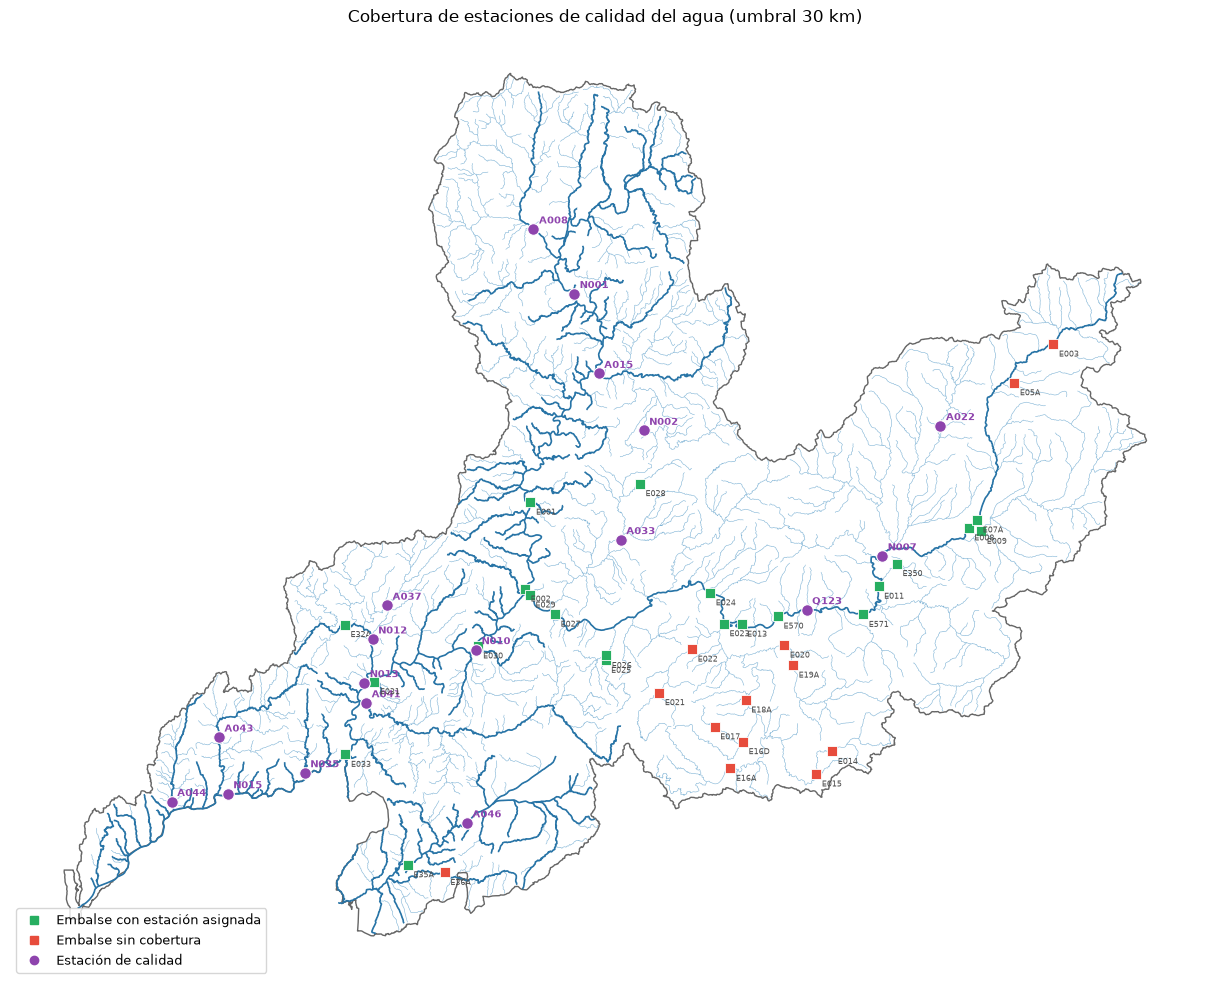

In [11]:
demarcacion = gpd.read_file(DIR_CARTO / "Division_Administrativa" / "Demarcacion_MiñoSil.shp").to_crs(CRS_PROYECTO)
principales = cauces[cauces["CODPK"].str.count("-") <= 2]

cubiertos = set(asignacion["ID_emb"])
emb_plot = embalses_gdf.assign(cubierto=embalses_gdf["ID"].isin(cubiertos))

fig, ax = plt.subplots(figsize=(14, 10))
demarcacion.boundary.plot(ax=ax, color="0.4", linewidth=1)
cauces.plot(ax=ax, color="#7fb3d5", linewidth=0.4, zorder=1)
principales.plot(ax=ax, color="#2874a6", linewidth=1.2, zorder=2)

emb_plot[~emb_plot["cubierto"]].plot(ax=ax, color="#e74c3c", marker="s", markersize=45,
                                     zorder=3, edgecolor="white", linewidth=0.6)
emb_plot[emb_plot["cubierto"]].plot(ax=ax, color="#27ae60", marker="s", markersize=45,
                                    zorder=3, edgecolor="white", linewidth=0.6)
calidad_gdf.plot(ax=ax, color="#8e44ad", marker="o", markersize=70,
                 zorder=4, edgecolor="white", linewidth=0.8)

for _, r in calidad_gdf.iterrows():
    ax.annotate(r["ID"], (r.geometry.x, r.geometry.y), xytext=(4, 4),
                textcoords="offset points", fontsize=7, color="#8e44ad", weight="bold")
for _, r in emb_plot.iterrows():
    ax.annotate(r["ID"], (r.geometry.x, r.geometry.y), xytext=(4, -9),
                textcoords="offset points", fontsize=6, color="0.3")

ax.legend(handles=[
    Line2D([], [], color="#27ae60", marker="s", ls="", label="Embalse con estación asignada"),
    Line2D([], [], color="#e74c3c", marker="s", ls="", label="Embalse sin cobertura"),
    Line2D([], [], color="#8e44ad", marker="o", ls="", label="Estación de calidad"),
], loc="lower left", fontsize=9)

ax.set_title(f"Cobertura de estaciones de calidad del agua (umbral {UMBRAL_KM} km)")
ax.set_axis_off()
fig.tight_layout()
fig.savefig(DIR_FIGURAS / "5_2_cobertura_calidad_embalses.png", dpi=150, bbox_inches="tight")
plt.show()

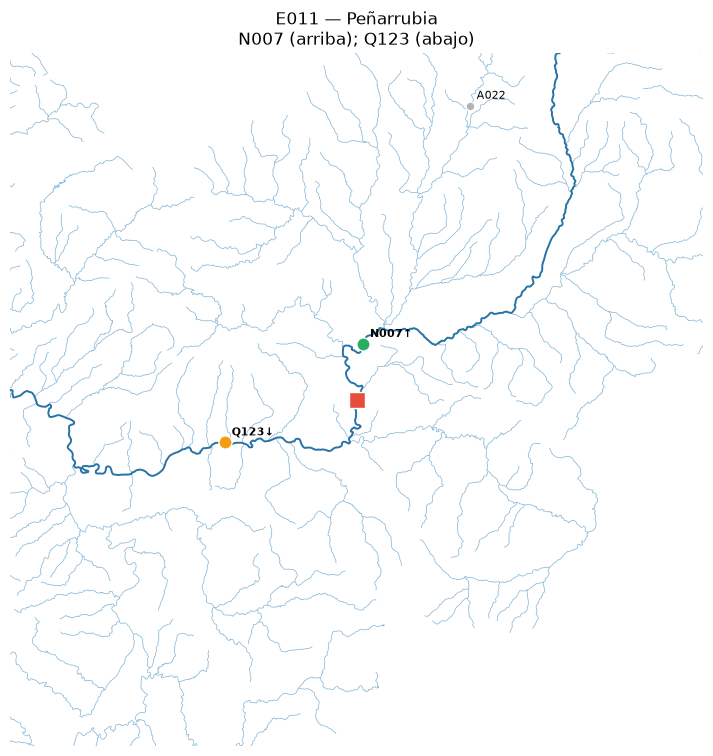

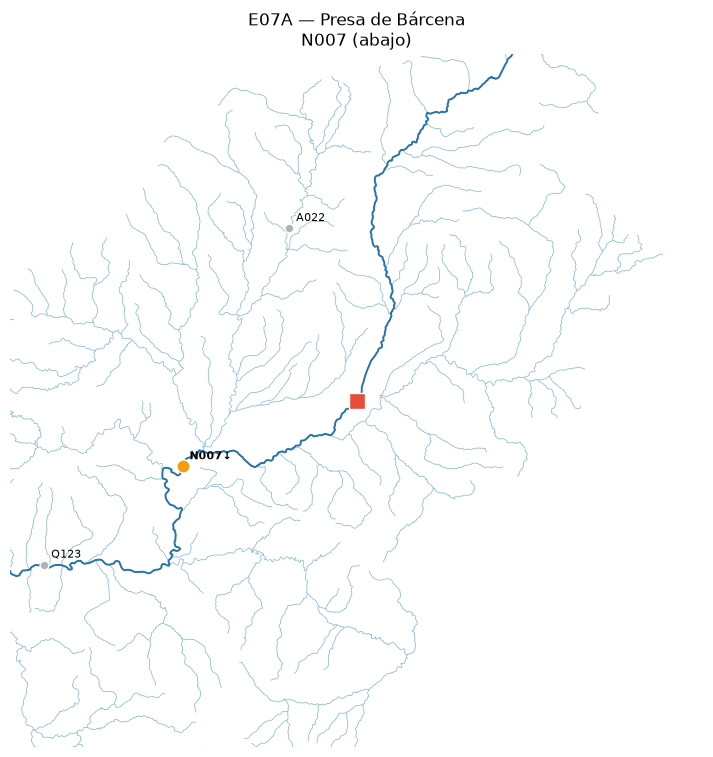

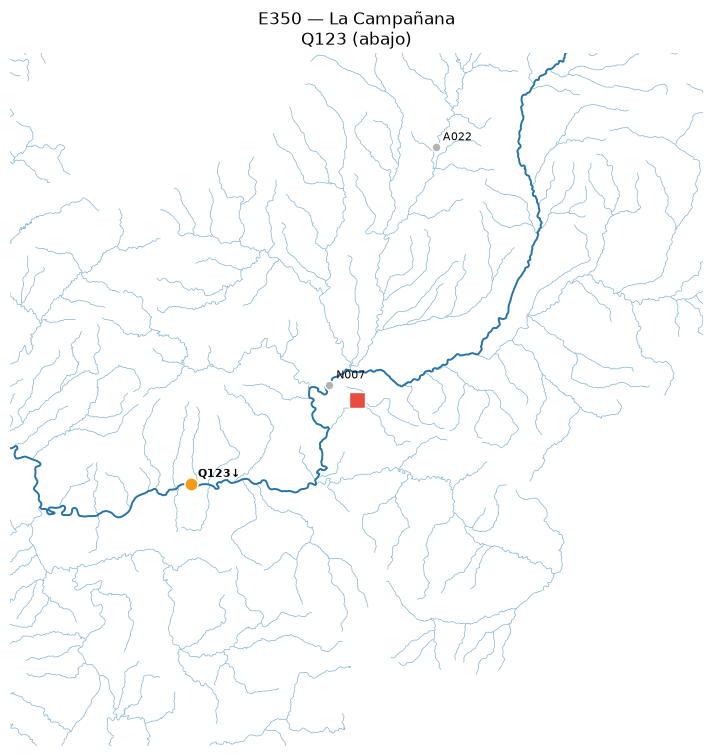

In [12]:
def plot_embalse(id_emb, margen_km=40):
    """Detalle de un embalse y las estaciones de calidad de su entorno."""
    emb = embalses_gdf[embalses_gdf["ID"] == id_emb].iloc[0]
    asignadas = dict(zip(asignacion.loc[asignacion["ID_emb"] == id_emb, "ID_cal"],
                         asignacion.loc[asignacion["ID_emb"] == id_emb, "relacion"]))
    m = margen_km * 1000

    fig, ax = plt.subplots(figsize=(9, 9))
    cauces.plot(ax=ax, color="#7fb3d5", linewidth=0.5)
    principales.plot(ax=ax, color="#2874a6", linewidth=1.4)
    ax.scatter(emb.geometry.x, emb.geometry.y, c="#e74c3c", marker="s", s=140,
               edgecolor="white", zorder=5)

    for _, r in calidad_gdf.iterrows():
        rel = asignadas.get(r["ID"])
        ax.scatter(r.geometry.x, r.geometry.y,
                   c={"arriba": "#27ae60", "abajo": "#f39c12"}.get(rel, "0.7"),
                   marker="o", s=90 if rel else 40, edgecolor="white", zorder=4)
        etiqueta = f"{r['ID']}{'↑' if rel == 'arriba' else '↓' if rel == 'abajo' else ''}"
        ax.annotate(etiqueta, (r.geometry.x, r.geometry.y), xytext=(5, 5),
                    textcoords="offset points", fontsize=8, weight="bold" if rel else "normal")

    ax.set_xlim(emb.geometry.x - m, emb.geometry.x + m)
    ax.set_ylim(emb.geometry.y - m, emb.geometry.y + m)
    ax.set_title(f"{id_emb} — {emb['Nombre']}\n"
                 f"{'; '.join(f'{k} ({v})' for k, v in asignadas.items()) or 'sin cobertura'}")
    ax.set_axis_off()
    plt.show()

# Casos de control: relaciones que los criterios descartados resolvían mal
plot_embalse("E011")   # Peñarrubia: N007 aguas arriba, Q123 aguas abajo
plot_embalse("E07A")   # Bárcena: N007 aguas abajo; el Cua entra al Sil por debajo
plot_embalse("E350")   # La Campañana: N007 a 3,5 km pero sin conexión de drenaje

## 10. Conclusiones

De los 35 embalses del SAIH:

- **35** cuentan con estaciones meteorológicas en un radio de 25 km, con una mediana de 10 estaciones por embalse entre las redes del SAIH y de AEMET.
- **20** disponen de estación hidrológica en río aguas arriba dentro de 30 km.
- **22** disponen de estación de calidad del agua hidrológicamente conectada dentro de 30 km, de los cuales 11 la tienen aguas arriba y 15 aguas abajo.
- **17** reúnen los tres tipos de estación.

La cobertura de calidad está condicionada por el despliegue de la red, concentrada en
los tramos bajos de los cauces principales. Ello introduce un sesgo relevante: los embalses con cobertura tienden a ser aprovechamientos fluyentes de menor variabilidad del porcentaje de llenado, mientras que los embalses de regulación estacional de
cabecera quedan mayoritariamente sin estación asociada. Este condicionante determina el alcance del diseño experimental y se discute en el capítulo de limitaciones.

Las variables hidrológicas del propio embalse (caudal de aportación y de salida) están disponibles para la totalidad de los embalses, por lo que la ausencia de estación de aforo en río no impide disponer de información hidrológica en el modelado.

In [13]:
APORTACION = {"MAIAPORT", "ACAPORT"}
SALIDA = {"MACQSALR", "MAIQSALR", "MAIQTSAL", "MACQTSAL", "ACQTSAL"}

cols_emb = pd.read_excel(DIR_RAW / "saih" / "Datos_Embalses.xlsx",
                         sheet_name="Datos_Embalses", nrows=0).columns

filas = []
for c in cols_emb[1:]:
    m = PATRON_COL.match(str(c).strip())
    if m:
        est, var = m.group(1).upper(), m.group(2).upper()
        est = est if est in set(maestro["ID_SAIH"]) else normalizar_id_embalse(est)
        filas.append({"ID": est, "grupo": "aportacion" if var in APORTACION
                      else "salida" if var in SALIDA else "otra"})

disp = pd.DataFrame(filas).query("grupo != 'otra'").drop_duplicates()
tabla = disp.assign(v=True).pivot_table(index="ID", columns="grupo", values="v",
                                        fill_value=False, aggfunc="first")

print(f"Embalses con aportación: {tabla.get('aportacion', pd.Series(dtype=bool)).sum()} de 35")
print(f"Embalses con salida: {tabla.get('salida', pd.Series(dtype=bool)).sum()} de 35")
print()
print(tabla.to_string())

Embalses con aportación: 36 de 35
Embalses con salida: 36 de 35

grupo  aportacion  salida
ID                       
E001         True    True
E002         True    True
E003         True    True
E008         True    True
E009         True    True
E011         True    True
E013         True    True
E014         True    True
E015         True    True
E017         True    True
E020         True    True
E021         True    True
E022         True    True
E023         True    True
E024         True    True
E025         True    True
E026         True    True
E027         True    True
E028         True    True
E029         True    True
E030         True    True
E031         True    True
E033         True    True
E03S         True    True
E05A         True    True
E07A         True    True
E16A         True    True
E16D         True    True
E18A         True    True
E19A         True    True
E32A         True    True
E350         True    True
E35A         True    True
E36A         True    True

In [14]:
# --- Metadatos de presa del Anuario: niveles de referencia ---
# El Anuario publica el máximo nivel normal de embalse (mnne) y el máximo nivel de
# avenida (mna), ambos en cota (msnm). El SAIH registra el nivel diario en la misma
# unidad, lo que permite contrastar los máximos observados con ambas referencias y
# valorar si los porcentajes de llenado superiores al 100% corresponden a explotación
# dentro del resguardo de avenida.

CSV_KWARGS = {"sep": ";", "encoding": "latin-1"}

crosswalk = pd.read_parquet(DIR_PROCESSED / "crosswalk_anuario_saih.parquet")
emb_anuario = pd.read_csv(DIR_RAW / "anuario" / "embalse.csv", **CSV_KWARGS)

referencias = (crosswalk[["ref_ceh", "ID_SAIH"]]
               .merge(emb_anuario[["ref_ceh", "nom_embalse", "mnne", "mna", "nae"]],
                      on="ref_ceh", how="left"))

# --- Niveles y volúmenes máximos observados en el SAIH ---
NIVEL = {"MAINEMBA", "AINEMBA"}
VOLUMEN = {"MACVEMBA", "MAIVEMBA", "ACVEMBA"}

emb_datos = pd.read_excel(DIR_RAW / "saih" / "Datos_Embalses.xlsx",
                          sheet_name="Datos_Embalses", skiprows=[1, 2])

def columnas_por_variable(columnas, grupo):
    """Mapa identificador de embalse -> nombre de columna, para un grupo de variables."""
    salida = {}
    for c in columnas:
        m = PATRON_COL.match(str(c).strip())
        if m and m.group(2).upper() in grupo:
            est = m.group(1).upper()
            est = est if est in set(maestro["ID_SAIH"]) else normalizar_id_embalse(est)
            if est:
                salida[est] = c
    return salida

col_nivel = columnas_por_variable(emb_datos.columns[1:], NIVEL)
col_volumen = columnas_por_variable(emb_datos.columns[1:], VOLUMEN)

observado = pd.DataFrame({
    "ID_SAIH": list(col_nivel),
    "nivel_max_obs": [emb_datos[c].max() for c in col_nivel.values()],
})
observado["volumen_max_obs"] = observado["ID_SAIH"].map(
    {k: emb_datos[v].max() for k, v in col_volumen.items()})

# --- Comparación ---
comp = (observado
        .merge(referencias[["ID_SAIH", "mnne", "mna"]], on="ID_SAIH", how="left")
        .merge(maestro[["ID_SAIH", "Nombre_SAIH", "Capacidad_hm3"]], on="ID_SAIH", how="left"))

comp["pct_max"] = comp["volumen_max_obs"] / comp["Capacidad_hm3"] * 100
comp["sobre_mnne_m"] = comp["nivel_max_obs"] - comp["mnne"]
comp["margen_mna_m"] = comp["mna"] - comp["nivel_max_obs"]

resultado = comp[comp["mnne"].notna()].copy()

print(f"Embalses con referencias de nivel en el Anuario: {len(resultado)} de {len(comp)}\n")

print("=== Embalses que superan el 100% de llenado ===")
sup = resultado[resultado["pct_max"] > 100].sort_values("pct_max", ascending=False)
print(sup[["ID_SAIH", "Nombre_SAIH", "pct_max", "nivel_max_obs",
           "mnne", "mna", "sobre_mnne_m", "margen_mna_m"]].round(2).to_string(index=False))

print("\n=== Resto ===")
resto = resultado[resultado["pct_max"] <= 100].sort_values("pct_max", ascending=False)
print(resto[["ID_SAIH", "Nombre_SAIH", "pct_max", "nivel_max_obs",
             "mnne", "mna", "sobre_mnne_m"]].round(2).to_string(index=False))

Embalses con referencias de nivel en el Anuario: 33 de 35

=== Embalses que superan el 100% de llenado ===
ID_SAIH Nombre_SAIH  pct_max  nivel_max_obs  mnne   mna  sobre_mnne_m  margen_mna_m
   E003    As Rozas   157.46         959.46 959.5   0.0         -0.04       -959.46
   E022   Guistolas   105.50         699.85 700.0 700.5         -0.15          0.65
   E011  Peñarrubia   105.17         394.45 394.4 394.9          0.05          0.45
   E013  San Martin   105.10         290.26 290.0   0.0          0.26       -290.26
   E029   San Pedro   100.70         129.87 130.0 132.0         -0.13          2.13
   E028   Vilasouto   100.15         473.25 473.0 474.2          0.25          0.95
   E027 San Esteban   100.02         228.98 229.0 229.0         -0.02          0.02

=== Resto ===
ID_SAIH        Nombre_SAIH  pct_max  nivel_max_obs   mnne    mna  sobre_mnne_m
   E16A  As Portas - Presa    99.90         881.94  882.0  884.0         -0.06
   E021          Chandrexa    99.77         987.

In [15]:
import sys
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np

sys.path.append("..")
from src.saih import id_estacion, num_saih, normalizar_id_embalse, PATRON_COL

DIR_RAW = Path("../data/raw")
DIR_EXTERNAL = Path("../data/external")
DIR_INTERIM = Path("../data/interim")
DIR_PROCESSED = Path("../data/processed")

CRS_PROYECTO = "EPSG:25829"
DIR_CARTO = DIR_EXTERNAL / "Datos-Cartograficos-Plan-Hidrologico-2022-2027"

HOJAS = [
    ("Datos_Embalses.xlsx", "Datos_Embalses"),
    ("Datos_Estaciones.xlsx", "Datos_Nivel"),
    ("Datos_Estaciones.xlsx", "Datos_Caudal"),
    ("Datos_Estaciones.xlsx", "Datos_Precipitación"),
    ("Datos_Estaciones.xlsx", "Datos_TempAmb"),
    ("Datos_Estaciones_Calidad.xlsx", "Datos_Calidad"),
]

## 1. Capa de estaciones del SAIH

Se construye una capa geográfica con todas las estaciones presentes en los datos y sus
coordenadas, indicando qué tipos de variable mide cada una. Las estaciones ubicadas en embalses emplean en las hojas de datos una codificación distinta a la de las hojas de identificación (`E005A` frente a `E05A`), por lo que la correspondencia se establece
sobre la parte numérica del identificador.

In [16]:
def cargar_identificacion(fichero):
    df = pd.read_excel(DIR_RAW / "saih" / fichero,
                       sheet_name="Identificación Estaciones", skiprows=[1])
    df.columns = ["ID", "Nombre", "Municipio", "Provincia", "Sistema", "X", "Y"]
    df["ID"] = df["ID"].astype(str).str.strip()
    return df[df["ID"].ne("nan")]

ident = pd.concat([
    cargar_identificacion("Datos_Estaciones.xlsx"),
    cargar_identificacion("Datos_Embalses.xlsx"),
], ignore_index=True).drop_duplicates(subset="ID")

ident["Sistema"] = ident["Sistema"].astype(str).str.strip().replace({"Sil Inf": "Sil Inferior"})
ident[["X", "Y"]] = ident[["X", "Y"]].apply(pd.to_numeric, errors="coerce")

print(f"Estaciones con coordenadas: {len(ident)}")
print(f"Sistemas: {sorted(ident['Sistema'].unique())}")

Estaciones con coordenadas: 115
Sistemas: ['Cabe', 'Limia', 'Miño Alto', 'Miño Bajo', 'Sil Inferior', 'Sil Superior']


In [17]:
# Tipos de variable que mide cada estación, según la hoja en que aparece
TIPO_POR_HOJA = {
    "Datos_Embalses": "embalse",
    "Datos_Nivel": "nivel_rio",
    "Datos_Caudal": "caudal_rio",
    "Datos_Precipitación": "precipitacion",
    "Datos_TempAmb": "temp_ambiente",
    "Datos_Calidad": "calidad",
}

registros = []
for fichero, hoja in HOJAS:
    cols = pd.read_excel(DIR_RAW / "saih" / fichero, sheet_name=hoja, nrows=0).columns
    for est in {i for i in (id_estacion(c) for c in cols[1:]) if i}:
        registros.append({"id_datos": est, "tipo": TIPO_POR_HOJA[hoja]})

tipos = (pd.DataFrame(registros)
         .drop_duplicates()
         .groupby("id_datos")["tipo"].apply(lambda s: sorted(s)).reset_index())

# Correspondencia id_datos -> id_identificacion (por parte numérica para embalses)
num_a_id = ident.assign(num=ident["ID"].apply(num_saih)).dropna(subset=["num"])
num_a_id = num_a_id.set_index("num")["ID"].to_dict()
ids_ident = set(ident["ID"])

def resolver(id_datos):
    """Correspondencia entre el identificador de las hojas de datos y el de las
    hojas de identificación. Devuelve None si no existe correspondencia."""
    if id_datos in ids_ident:
        return id_datos
    norm = normalizar_id_embalse(id_datos)
    return norm if norm in ids_ident else None

tipos["ID"] = tipos["id_datos"].apply(resolver)
sin_resolver = sorted(tipos.loc[tipos["ID"].isna(), "id_datos"])
print(f"Estaciones en datos: {len(tipos)} | sin correspondencia: {sin_resolver}")

Estaciones en datos: 124 | sin correspondencia: ['A004', 'A021', 'E007B', 'E03S']


In [18]:
estaciones = tipos.dropna(subset=["ID"]).merge(ident, on="ID", how="left")

estaciones_gdf = gpd.GeoDataFrame(
    estaciones,
    geometry=gpd.points_from_xy(estaciones["X"], estaciones["Y"]),
    crs=CRS_PROYECTO,
)

# Resumen por tipo de variable
from collections import Counter
conteo = Counter(t for lista in estaciones_gdf["tipo"] for t in lista)
for tipo, n in sorted(conteo.items()):
    print(f"{tipo:<16} {n:>4}")

print(f"\nTotal estaciones georreferenciadas: {len(estaciones_gdf)}")

calidad            18
caudal_rio         54
embalse            35
nivel_rio          60
precipitacion      90
temp_ambiente      93

Total estaciones georreferenciadas: 120


## 2. Evaluación de criterios de asignación

Antes de fijar el criterio de asignación se evalúan tres alternativas de agregación espacial, midiendo cuántas estaciones de medida quedarían asociadas a cada embalse:
subcuenca hidrográfica, cuenca vertiente de la masa de agua y sistema de explotación.

El criterio adecuado debe evitar dos extremos: ser tan restrictivo que deje embalses sin
información asociada, o tan amplio que asocie estaciones sin relación hidrológica real
con el embalse.

In [19]:
subcuencas = gpd.read_file(DIR_CARTO / "Hidrografia" / "Subcuencas.shp").to_crs(CRS_PROYECTO)
vertientes = gpd.read_file(DIR_CARTO / "Masas_Agua" / "Cuencas_vertientes.shp").to_crs(CRS_PROYECTO)

es_embalse = estaciones_gdf["tipo"].apply(lambda t: "embalse" in t)
embalses_gdf = estaciones_gdf[es_embalse].copy()
medida_gdf = estaciones_gdf[~es_embalse].copy()

print(f"Embalses: {len(embalses_gdf)} | Estaciones de medida: {len(medida_gdf)}\n")

for nombre, gdf, col in [("Subcuencas", subcuencas, "COD_CUENCA"),
                         ("Cuencas vertientes", vertientes, "Cod_MSPF")]:
    emb = gpd.sjoin(embalses_gdf[["ID", "geometry"]], gdf[[col, "geometry"]],
                    how="left", predicate="within")
    est = gpd.sjoin(medida_gdf[["ID", "geometry"]], gdf[[col, "geometry"]],
                    how="left", predicate="within")

    conteo = (emb[["ID", col]]
              .merge(est[["ID", col]], on=col, how="left", suffixes=("_emb", "_est"))
              .groupby("ID_emb")["ID_est"].nunique()
              .reindex(embalses_gdf["ID"]).fillna(0))

    print(f"=== {nombre} ({len(gdf)} polígonos) ===")
    print(f"Estaciones por embalse -> mediana {conteo.median():.0f} | máx {conteo.max():.0f}")
    print(f"Embalses sin ninguna estación: {(conteo == 0).sum()} de {len(conteo)}\n")

conteo_sist = (embalses_gdf[["ID", "Sistema"]]
               .merge(medida_gdf[["ID", "Sistema"]], on="Sistema", how="left",
                      suffixes=("_emb", "_est"))
               .groupby("ID_emb")["ID_est"].nunique()
               .reindex(embalses_gdf["ID"]).fillna(0))

print("=== Sistema de explotación ===")
print(f"Estaciones por embalse -> mediana {conteo_sist.median():.0f} | máx {conteo_sist.max():.0f}")
print(f"Embalses sin ninguna estación: {(conteo_sist == 0).sum()} de {len(conteo_sist)}")

Embalses: 35 | Estaciones de medida: 85

=== Subcuencas (978 polígonos) ===
Estaciones por embalse -> mediana 0 | máx 1
Embalses sin ninguna estación: 24 de 35

=== Cuencas vertientes (286 polígonos) ===
Estaciones por embalse -> mediana 0 | máx 3
Embalses sin ninguna estación: 21 de 35

=== Sistema de explotación ===
Estaciones por embalse -> mediana 10 | máx 29
Embalses sin ninguna estación: 0 de 35


In [20]:
calidad_gdf = medida_gdf[medida_gdf["tipo"].apply(lambda t: "calidad" in t)].copy()
print(f"Estaciones de calidad: {len(calidad_gdf)}")
print(calidad_gdf["Sistema"].value_counts().to_string())

# Distancia de cada embalse a la estación de calidad más próxima
dist = embalses_gdf.geometry.apply(lambda p: calidad_gdf.distance(p).min()) / 1000
resumen = pd.DataFrame({
    "ID": embalses_gdf["ID"].values,
    "Nombre": embalses_gdf["Nombre"].values,
    "Sistema": embalses_gdf["Sistema"].values,
    "dist_calidad_km": dist.values,
}).sort_values("dist_calidad_km")

print(f"\nDistancia a la estación de calidad más próxima (km):")
print(f"  mediana {resumen['dist_calidad_km'].median():.1f} | máx {resumen['dist_calidad_km'].max():.1f}")
for umbral in [10, 20, 30, 50]:
    n = (resumen["dist_calidad_km"] <= umbral).sum()
    print(f"  Embalses con calidad a menos de {umbral} km: {n} de 35")

print()
print(resumen.to_string(index=False))

Estaciones de calidad: 18
Sistema
Miño Bajo       9
Miño Alto       4
Sil Superior    2
Cabe            1
Limia           1
Sil Inferior    1

Distancia a la estación de calidad más próxima (km):
  mediana 18.0 | máx 37.2
  Embalses con calidad a menos de 10 km: 8 de 35
  Embalses con calidad a menos de 20 km: 20 de 35
  Embalses con calidad a menos de 30 km: 29 de 35
  Embalses con calidad a menos de 50 km: 35 de 35

  ID                 Nombre      Sistema  dist_calidad_km
E030                  Velle    Miño Bajo         0.863449
E031               Castrelo    Miño Bajo         2.158077
E350           La Campañana Sil Superior         3.534442
E570               Santiago Sil Inferior         6.164617
E011             Peñarrubia Sil Inferior         6.463840
E32A     Albarellos - Presa    Miño Bajo         6.584566
E020          Santa Eulalia Sil Inferior         8.832667
E033                Frieira    Miño Bajo         9.431683
E028              Vilasouto         Cabe        11.25799

In [21]:
COL_SUP = "Sup_ac_km2"

# Asignación de embalses y estaciones de calidad a su cuenca vertiente
def asignar_vertiente(gdf):
    j = gpd.sjoin(
        gdf[["ID", "Nombre", "Sistema", "geometry"]],
        vertientes[["Cod_MSPF", "Nombre", COL_SUP, "geometry"]].rename(
            columns={"Nombre": "Nombre_MSPF"}),
        how="left", predicate="within",
    )
    return j.drop(columns="index_right")

emb_v = asignar_vertiente(embalses_gdf)
cal_v = asignar_vertiente(calidad_gdf)

print(f"Embalses sin vertiente asignada: {emb_v['Cod_MSPF'].isna().sum()}")
print(f"Estaciones de calidad sin vertiente asignada: {cal_v['Cod_MSPF'].isna().sum()}")
print(f"Embalses sin dato de superficie acumulada: {emb_v[COL_SUP].isna().sum()}")
print(f"Estaciones sin dato de superficie acumulada: {cal_v[COL_SUP].isna().sum()}\n")

print("Superficie acumulada de los embalses (km2):")
print(emb_v[["ID", "Nombre", COL_SUP]].sort_values(COL_SUP).to_string(index=False))

Embalses sin vertiente asignada: 0
Estaciones de calidad sin vertiente asignada: 0
Embalses sin dato de superficie acumulada: 0
Estaciones sin dato de superficie acumulada: 0

Superficie acumulada de los embalses (km2):
  ID                 Nombre  Sup_ac_km2
E017                  Cenza       23.78
E350           La Campañana       41.80
E025          Leboreiro Mao       56.59
E05A    Matalavilla - Presa       58.07
E014          San Sebastián      111.91
E026             Edrada Mao      125.50
E021              Chandrexa      128.51
E015                   Pías      140.25
E36A          Salas - Presa      177.24
E028              Vilasouto      192.55
E32A     Albarellos - Presa      200.26
E16A      As Portas - Presa      249.00
E022              Guistolas      250.38
E19A          Prada - Presa      256.00
E020          Santa Eulalia      327.40
E003               As Rozas      449.15
E009            Montearenas      708.67
E16D As Portas - C.H. Conso      729.76
E18A            Bao 

In [22]:
pares = emb_v[["ID", "Nombre", "Sistema", COL_SUP, "geometry"]].rename(
    columns={"ID": "ID_emb", "Nombre": "Nombre_emb", COL_SUP: "sup_emb"}
).merge(
    cal_v[["ID", "Nombre", COL_SUP, "geometry"]].rename(
        columns={"ID": "ID_cal", "Nombre": "Nombre_cal", COL_SUP: "sup_cal"}),
    how="cross"
)

pares["dist_km"] = pares.apply(
    lambda r: r["geometry_x"].distance(r["geometry_y"]) / 1000, axis=1)
pares["aguas_arriba"] = pares["sup_cal"] < pares["sup_emb"]

arriba = pares[pares["aguas_arriba"]]

print("=== Cobertura de calidad aguas arriba ===")
for umbral in [20, 30, 50, 100]:
    n = arriba[arriba["dist_km"] <= umbral]["ID_emb"].nunique()
    print(f"  Embalses con estación aguas arriba a menos de {umbral} km: {n} de 35")

print(f"\nEmbalses sin ninguna estación aguas arriba (a cualquier distancia): "
      f"{35 - arriba['ID_emb'].nunique()}")

mejor = (arriba.sort_values("dist_km")
         .drop_duplicates("ID_emb")[["ID_emb", "Nombre_emb", "Sistema", "ID_cal", "Nombre_cal", "dist_km"]])
print("\nEstación de calidad aguas arriba más próxima a cada embalse:")
print(mejor.sort_values("dist_km").to_string(index=False))

=== Cobertura de calidad aguas arriba ===
  Embalses con estación aguas arriba a menos de 20 km: 9 de 35
  Embalses con estación aguas arriba a menos de 30 km: 19 de 35
  Embalses con estación aguas arriba a menos de 50 km: 22 de 35
  Embalses con estación aguas arriba a menos de 100 km: 29 de 35

Embalses sin ninguna estación aguas arriba (a cualquier distancia): 4

Estación de calidad aguas arriba más próxima a cada embalse:
ID_emb             Nombre_emb      Sistema ID_cal                    Nombre_cal    dist_km
  E570               Santiago Sil Inferior   Q123  Sil en O Barco de Valdeorras   6.164617
  E011             Peñarrubia Sil Inferior   N007            Río Sil en Requejo   6.463840
  E031               Castrelo    Miño Bajo   N012             Río Avia en Leiro   9.010230
  E033                Frieira    Miño Bajo   N035        Río Deva en As Regadas   9.431683
  E32A     Albarellos - Presa    Miño Bajo   A037   Río Arenteiro en Carballiño   9.760427
  E571                P

In [23]:
pares = emb_v[["ID", "Nombre", "Sistema", COL_SUP, "geometry"]].rename(
    columns={"ID": "ID_emb", "Nombre": "Nombre_emb", "Sistema": "sist_emb", COL_SUP: "sup_emb"}
).merge(
    cal_v[["ID", "Nombre", "Sistema", COL_SUP, "geometry"]].rename(
        columns={"ID": "ID_cal", "Nombre": "Nombre_cal", "Sistema": "sist_cal", COL_SUP: "sup_cal"}),
    how="cross"
)

pares["dist_km"] = pares.apply(
    lambda r: r["geometry_x"].distance(r["geometry_y"]) / 1000, axis=1)
pares["aguas_arriba"] = pares["sup_cal"] < pares["sup_emb"]
pares["mismo_sistema"] = pares["sist_emb"] == pares["sist_cal"]

valido = pares[pares["aguas_arriba"] & pares["mismo_sistema"]]

print("=== Criterio combinado: mismo sistema + aguas arriba ===")
for umbral in [20, 30, 50]:
    n = valido[valido["dist_km"] <= umbral]["ID_emb"].nunique()
    print(f"  Embalses cubiertos a menos de {umbral} km: {n} de 35")

print(f"\nEmbalses sin cobertura a ninguna distancia: {35 - valido['ID_emb'].nunique()}")

mejor = (valido.sort_values("dist_km").drop_duplicates("ID_emb")
         [["ID_emb", "Nombre_emb", "sist_emb", "ID_cal", "Nombre_cal", "dist_km"]])
print()
print(mejor.sort_values("dist_km").to_string(index=False))

=== Criterio combinado: mismo sistema + aguas arriba ===
  Embalses cubiertos a menos de 20 km: 7 de 35
  Embalses cubiertos a menos de 30 km: 14 de 35
  Embalses cubiertos a menos de 50 km: 15 de 35

Embalses sin cobertura a ninguna distancia: 18

ID_emb         Nombre_emb     sist_emb ID_cal                   Nombre_cal   dist_km
  E570           Santiago Sil Inferior   Q123 Sil en O Barco de Valdeorras  6.164617
  E031           Castrelo    Miño Bajo   N012            Río Avia en Leiro  9.010230
  E033            Frieira    Miño Bajo   N035       Río Deva en As Regadas  9.431683
  E32A Albarellos - Presa    Miño Bajo   A037  Río Arenteiro en Carballiño  9.760427
  E013         San Martin Sil Inferior   Q123 Sil en O Barco de Valdeorras 14.059558
  E35A    Conchas - Presa        Limia   A046    Río Limia en Ponteliñares 15.269988
  E023        Montefurado Sil Inferior   Q123 Sil en O Barco de Valdeorras 17.680605
  E024          Sequeiros Sil Inferior   Q123 Sil en O Barco de Valdeor

In [24]:
for carpeta in sorted(DIR_CARTO.iterdir()):
    if carpeta.is_dir():
        shps = sorted(p.name for p in carpeta.glob("*.shp"))
        if shps:
            print(f"{carpeta.name}/")
            for s in shps:
                print(f"    {s}")

Division_Administrativa/
    Comunidades_Autonomas.shp
    Demarcacion_MiñoSil.shp
    Municipios.shp
    Poblaciones.shp
    Provincias.shp
Especies_Amenazadas/
    Charadrius_alexandrinus.shp
    Emberiza_schoeniclus_lusitanica.shp
    Emys_orbicularis_linea.shp
    Emys_orbicularis_poligono.shp
    Galemys_pyrenaicus.shp
    Isoetes_fluitans.shp
    Margaritifera_margaritifera.shp
Estado_OMA/
    MASb_Estado_OMA.shp
    MASp_Costera_Estado_OMA.shp
    MASp_Embalse_Estado_OMA.shp
    MASp_Lago_Estado_OMA.shp
    MASp_Rio_Estado_OMA.shp
    MASp_Transicion_Estado_OMA.shp
Hidrografia/
    CaucesEjes_1_25000.shp
    CaucesEjes_1_50000.shp
    CaucesMargenes_1_25000.shp
    Embalses_1_25000.shp
    Embalses_1_50000.shp
    Lagos_1_25000.shp
    Subcuencas.shp
Masas_Agua/
    Cuencas_vertientes.shp
    MASb.shp
    MASp_Costera.shp
    MASp_Embalse.shp
    MASp_Lago.shp
    MASp_Rio.shp
    MASp_Transicion.shp
Otras_Infraestructuras/
    Campos_golf.shp
    Centrales_Hidroelectricas.shp
 

In [25]:
CANDIDATAS = [
    ("Hidrografia", "CaucesEjes_1_50000.shp"),
    ("Hidrografia", "CaucesEjes_1_25000.shp"),
    ("Red_Hidrografica_Basica", "Red_Hidrografica_Basica_linea.shp"),
]

for carpeta, fichero in CANDIDATAS:
    gdf = gpd.read_file(DIR_CARTO / carpeta / fichero).to_crs(CRS_PROYECTO)
    print(f"=== {fichero} ===")
    print(f"Tramos: {len(gdf)} | geometrías: {gdf.geom_type.value_counts().to_dict()}")
    print(f"Longitud total: {gdf.length.sum()/1000:,.0f} km")
    print(f"Columnas: {list(gdf.columns)}")
    print(gdf.drop(columns='geometry').head(3).to_string(index=False))
    print()

=== CaucesEjes_1_50000.shp ===
Tramos: 878 | geometrías: {'LineString': 878}
Longitud total: 8,263 km
Columnas: ['CAUNOM', 'CAUNOM2', 'COD_CAUCE', 'CODDECIMAL', 'CODPK', 'CONFCOD', 'CUENCOD', 'CAUPK1', 'CAUPK2', 'CAUPK3', 'CAUPK4', 'CAUPK5', 'CAUPK6', 'CAUPK7', 'CAUPK8', 'CAUPK9', 'CAUPKDES', 'CAUCEDEX', 'CAULONG', 'CAUIDALFA', 'geometry']
    CAUNOM CAUNOM2 COD_CAUCE            CODDECIMAL                               CODPK CONFCOD  CUENCOD  CAUPK1 CAUPK2 CAUPK3 CAUPK4 CAUPK5 CAUPK6 CAUPK7 CAUPK8 CAUPK9 CAUPKDES CAUCEDEX  CAULONG  CAUIDALFA
 PACIOS DE     NaN   NO01922    1.4400.290.140.060        NO-4400-14548I-05423D-00950D      NO     4400 014793I 18959D 00987D 000000 000000 000000 000000 000000 000000   000000      NaN   9774.0     1941.0
CABANAS DE     NaN   NO01924 1.4400.290.210.010.10 NO-4400-14548I-06757I-00290I-00290I      NO     4400 014793I 20273I 00293I 00247I 000000 000000 000000 000000 000000   000000      NaN   5246.0     1943.0
    GRANDE     NaN   NO01929 1.4400.290.

In [26]:
cauces = gpd.read_file(DIR_CARTO / "Hidrografia" / "CaucesEjes_1_50000.shp").to_crs(CRS_PROYECTO)

for nombre in ["MIÑO", "SIL", "CABE", "AVIA", "CUA", "LIMIA"]:
    sel = cauces[cauces["CAUNOM"].str.contains(nombre, case=False, na=False)]
    if len(sel):
        print(f"=== {nombre} ({len(sel)} tramos) ===")
        print(sel[["CAUNOM", "COD_CAUCE", "CODDECIMAL", "CODPK", "CAULONG"]]
              .head(3).to_string(index=False))
        print()

=== MIÑO (2 tramos) ===
  CAUNOM COD_CAUCE     CODDECIMAL                 CODPK  CAULONG
    MIÑO   NO01667         1.4400               NO-4400 315155.0
MIÑOTELO   NO02448 1.4400.920.020 NO-4400-29957D-00600D   9862.0

=== SIL (5 tramos) ===
     CAUNOM COD_CAUCE            CODDECIMAL                               CODPK  CAULONG
     SILVAN   NO01965    1.4400.290.330.050        NO-4400-14548I-10962I-02651I  13658.0
SILVA DE LA   NO02067 1.4400.290.450.090.30 NO-4400-14548I-15040I-02577I-00850I   7864.0
   SILVABOA   NO02171 1.4400.520.070.010.20 NO-4400-09800D-01632I-01684I-00434D   8725.0

=== CABE (1 tramos) ===
CAUNOM COD_CAUCE     CODDECIMAL                 CODPK  CAULONG
  CABE   NO01866 1.4400.290.040 NO-4400-14548I-00781D  55148.0

=== AVIA (1 tramos) ===
CAUNOM COD_CAUCE CODDECIMAL          CODPK  CAULONG
  AVIA   NO02152 1.4400.520 NO-4400-09800D  39346.0

=== CUA (1 tramos) ===
CAUNOM COD_CAUCE     CODDECIMAL                 CODPK  CAULONG
   CUA   NO02017 1.4400.290.440 NO

In [27]:
from shapely.geometry import Point

# El SIL no apareció porque head(3) cortó la lista
sil = cauces[cauces["CAUNOM"].str.strip().eq("SIL")]
print("=== SIL ===")
print(sil[["CAUNOM", "COD_CAUCE", "CODDECIMAL", "CODPK", "CAULONG"]].to_string(index=False))

# Sentido de digitalización: ¿el vértice inicial es desembocadura o cabecera?
mino = cauces[cauces["CAUNOM"].str.strip().eq("MIÑO")].iloc[0]
sil_geom = sil.iloc[0].geometry

# Punto de confluencia = extremo del Sil más cercano al Miño
extremos = [Point(sil_geom.coords[0]), Point(sil_geom.coords[-1])]
confluencia = min(extremos, key=lambda p: p.distance(mino.geometry))

pos = mino.geometry.project(confluencia)
print(f"\nLongitud del Miño: {mino.geometry.length/1000:.1f} km (campo CAULONG: {mino['CAULONG']/1000:.1f} km)")
print(f"Confluencia del Sil proyectada a {pos/1000:.1f} km del vértice inicial")
print(f"PK declarado en CODPK: 14548 -> {14548*10/1000:.1f} km si son decámetros")

=== SIL ===
CAUNOM COD_CAUCE CODDECIMAL          CODPK  CAULONG
   SIL   NO02610 1.4400.290 NO-4400-14548I 233998.0

Longitud del Miño: 315.2 km (campo CAULONG: 315.2 km)
Confluencia del Sil proyectada a 167.6 km del vértice inicial
PK declarado en CODPK: 14548 -> 145.5 km si son decámetros


In [28]:
from shapely.geometry import Point

def pk_confluencia(cauce_hijo, cauce_padre):
    """Distancia desde la desembocadura del cauce padre hasta la confluencia, en km."""
    extremos = [Point(cauce_hijo.geometry.coords[0]), Point(cauce_hijo.geometry.coords[-1])]
    conf = min(extremos, key=lambda p: p.distance(cauce_padre.geometry))
    return (cauce_padre.geometry.length - cauce_padre.geometry.project(conf)) / 1000

mino = cauces[cauces["CAUNOM"].str.strip().eq("MIÑO")].iloc[0]
sil = cauces[cauces["CAUNOM"].str.strip().eq("SIL")].iloc[0]

# Afluentes directos del Miño y del Sil, según prefijo de CODPK
for padre, nombre_padre in [(mino, "MIÑO"), (sil, "SIL")]:
    prefijo = padre["CODPK"] + "-"
    hijos = cauces[
        cauces["CODPK"].str.startswith(prefijo, na=False)
        & (cauces["CODPK"].str.count("-") == padre["CODPK"].count("-") + 1)
    ]
    print(f"=== Afluentes directos del {nombre_padre} ({len(hijos)}) ===")
    filas = []
    for _, h in hijos.iterrows():
        pk_declarado = int(h["CODPK"].split("-")[-1][:-1]) * 10 / 1000
        filas.append({
            "cauce": h["CAUNOM"],
            "pk_codpk_km": pk_declarado,
            "pk_geom_km": round(pk_confluencia(h, padre), 1),
        })
    df = pd.DataFrame(filas).sort_values("pk_codpk_km")
    df["desfase_km"] = (df["pk_geom_km"] - df["pk_codpk_km"]).round(1)
    print(df.head(12).to_string(index=False))
    print(f"Desfase: mediana {df['desfase_km'].median():.1f} km | "
          f"máx abs {df['desfase_km'].abs().max():.1f} km\n")

=== Afluentes directos del MIÑO (100) ===
            cauce  pk_codpk_km  pk_geom_km  desfase_km
         LAGOS DE         4.68         5.9         1.2
         CARVALLO         5.44         6.8         1.4
            TOLLO        10.05        11.2         1.1
    FABRICA DE LA        14.22        15.6         1.4
        BRAVOS DE        15.39        16.8         1.4
         PEGO DEL        15.68        17.0         1.3
     HOSPITAL DEL        18.57        20.0         1.4
     FURNIA DE LA        20.98        22.5         1.5
       LEIRIÑA DE        27.23        28.9         1.7
       SEIJAL DEL        28.68        30.3         1.6
            LOURO        30.07        31.7         1.6
FUENTE FERRERO DE        32.43        34.0         1.6
Desfase: mediana 2.7 km | máx abs 5.7 km

=== Afluentes directos del SIL (62) ===
              cauce  pk_codpk_km  pk_geom_km  desfase_km
       RIGUEIRO DEL         1.57         1.5        -0.1
               CABE         7.81         7.5   

In [29]:
def enganchar(gdf, cauces, max_dist_m=2000):
    """Asigna a cada punto el tramo de cauce más próximo y su posición sobre él."""
    filas = []
    for _, p in gdf.iterrows():
        d = cauces.distance(p.geometry)
        i = d.idxmin()
        cauce = cauces.loc[i]
        filas.append({
            "ID": p["ID"],
            "Nombre": p["Nombre"],
            "cauce": cauce["CAUNOM"],
            "codpk": cauce["CODPK"],
            "dist_cauce_m": round(d.min(), 1),
            "pos_desde_desemb_km": round(
                (cauce.geometry.length - cauce.geometry.project(p.geometry)) / 1000, 2),
        })
    return pd.DataFrame(filas)

emb_c = enganchar(embalses_gdf, cauces)
cal_c = enganchar(calidad_gdf, cauces)

print("=== Embalses ===")
print(emb_c.sort_values("dist_cauce_m", ascending=False).to_string(index=False))
print("\n=== Estaciones de calidad ===")
print(cal_c.sort_values("dist_cauce_m", ascending=False).to_string(index=False))

=== Embalses ===
  ID                 Nombre      cauce                               codpk  dist_cauce_m  pos_desde_desemb_km
E36A          Salas - Presa      SALAS                      NO-4500-01300I         320.5                16.13
E001                Belesar       MIÑO                             NO-4400         230.0               173.72
E002              Os Peares       MIÑO                             NO-4400         211.8               149.16
E19A          Prada - Presa      JARES        NO-4400-14548I-06757I-01394D         207.0                17.83
E028              Vilasouto        MAO        NO-4400-14548I-00781D-03059D         189.6                17.79
E16A      As Portas - Presa      CAMBA        NO-4400-14548I-06757I-04303I         160.6                19.65
E033                Frieira       MIÑO                             NO-4400         147.8                79.06
E32A     Albarellos - Presa       AVIA                      NO-4400-09800D         137.7               

In [30]:
CORRECCIONES = {"N010": "MIÑO", "E023": "SIL"}  # enganches forzados

def enganchar_corregido(gdf, cauces, correcciones):
    filas = []
    for _, p in gdf.iterrows():
        cand = cauces
        if p["ID"] in correcciones:
            cand = cauces[cauces["CAUNOM"].str.strip().eq(correcciones[p["ID"]])]
        d = cand.distance(p.geometry)
        c = cand.loc[d.idxmin()]
        filas.append({
            "ID": p["ID"], "Nombre": p["Nombre"],
            "cauce": c["CAUNOM"].strip(), "codpk": c["CODPK"],
            "pos_km": (c.geometry.length - c.geometry.project(p.geometry)) / 1000,
        })
    return pd.DataFrame(filas)

emb_c = enganchar_corregido(embalses_gdf, cauces, CORRECCIONES)
cal_c = enganchar_corregido(calidad_gdf, cauces, CORRECCIONES)

# Posición de la confluencia de cada cauce sobre su cauce padre (geometría, no CODPK)
geom_por_codpk = cauces.set_index("CODPK").geometry.to_dict()

def pos_confluencia(codpk_hijo, codpk_padre):
    """Posición de la desembocadura del cauce hijo sobre el padre, en km desde
    la desembocadura del padre."""
    hijo, padre = geom_por_codpk[codpk_hijo], geom_por_codpk[codpk_padre]
    extremos = [Point(hijo.coords[0]), Point(hijo.coords[-1])]
    conf = min(extremos, key=lambda p: p.distance(padre))
    return (padre.length - padre.project(conf)) / 1000

def esta_aguas_arriba(est, emb):
    """¿La estación drena hacia el embalse?"""
    if est["codpk"] == emb["codpk"]:
        return est["pos_km"] > emb["pos_km"]

    # El cauce de la estación debe colgar del cauce del embalse
    if not est["codpk"].startswith(emb["codpk"] + "-"):
        return False

    # La rama que baja hasta el cauce del embalse debe confluir aguas arriba de él
    resto = est["codpk"][len(emb["codpk"]) + 1:].split("-")
    rama = emb["codpk"] + "-" + resto[0]
    if rama not in geom_por_codpk:
        return False
    return pos_confluencia(rama, emb["codpk"]) > emb["pos_km"]

pares = emb_c.merge(cal_c, how="cross", suffixes=("_emb", "_cal"))
pares["aguas_arriba"] = pares.apply(
    lambda r: esta_aguas_arriba(
        {"codpk": r["codpk_cal"], "pos_km": r["pos_km_cal"]},
        {"codpk": r["codpk_emb"], "pos_km": r["pos_km_emb"]}), axis=1)

valido = pares[pares["aguas_arriba"]]
print(f"Embalses con alguna estación de calidad aguas arriba: "
      f"{valido['ID_emb'].nunique()} de {len(emb_c)}\n")
print(valido.groupby(["ID_emb", "Nombre_emb"])["Nombre_cal"]
      .apply(lambda s: ", ".join(sorted(s))).to_string())

Embalses con alguna estación de calidad aguas arriba: 14 de 35

ID_emb  Nombre_emb     
E001    Belesar            Río Ladra en Begonte, Río Miño en Lugo, Río Ne...
E002    Os Peares          Río Ladra en Begonte, Río Miño en Lugo, Río Ne...
E011    Peñarrubia                     Río Cua en Fabero, Río Sil en Requejo
E013    San Martin         Río Cua en Fabero, Río Sil en Requejo, Sil en ...
E023    Montefurado        Río Cua en Fabero, Río Sil en Requejo, Sil en ...
E024    Sequeiros          Río Cua en Fabero, Río Sil en Requejo, Sil en ...
E027    San Esteban        Río Cua en Fabero, Río Sil en Requejo, Sil en ...
E029    San Pedro          Río Cabe en Monforte de Lemos, Río Cua en Fabe...
E030    Velle              Río Cabe en Monforte de Lemos, Río Cua en Fabe...
E031    Castrelo           Río Cabe en Monforte de Lemos, Río Cua en Fabe...
E033    Frieira            Río Arenteiro en Carballiño, Río Arnoia en Arn...
E35A    Conchas - Presa                            Río Limia en P

In [31]:
calidad_raw = pd.read_excel(DIR_RAW / "saih" / "Datos_Estaciones_Calidad.xlsx",
                            sheet_name="Datos_Calidad", skiprows=[1, 2])
calidad_raw = calidad_raw.rename(columns={calidad_raw.columns[0]: "fecha"})
calidad_raw["fecha"] = pd.to_datetime(calidad_raw["fecha"])

filas = []
for col in calidad_raw.columns[1:]:
    est = id_estacion(col)
    s = calidad_raw.loc[calidad_raw[col].notna(), "fecha"]
    if est and len(s):
        filas.append({
            "ID": est,
            "variable": PATRON_COL.match(str(col).strip()).group(2).upper(),
            "n_dias": len(s),
            "desde": s.min(),
            "hasta": s.max(),
        })

cob = pd.DataFrame(filas)

resumen_cob = (cob.groupby("ID")
               .agg(n_variables=("variable", "nunique"),
                    dias_max=("n_dias", "max"),
                    desde=("desde", "min"),
                    hasta=("hasta", "max"))
               .reset_index())
resumen_cob["anios"] = ((resumen_cob["hasta"] - resumen_cob["desde"]).dt.days / 365.25).round(1)

cubiertos = set(valido["ID_cal"])
resumen_cob["asignada"] = resumen_cob["ID"].isin(cubiertos)

print(resumen_cob.sort_values("dias_max", ascending=False).to_string(index=False))

  ID  n_variables  dias_max      desde      hasta  anios  asignada
A043            7      8130 2001-01-01 2024-05-20   23.4     False
N001            7      8026 2001-01-01 2024-05-20   23.4      True
A015            6      7913 2001-01-01 2024-05-20   23.4      True
A033            7      7834 2001-01-01 2024-05-20   23.4      True
A008            6      7538 2001-01-03 2024-05-20   23.4      True
N013            6      7393 2001-01-01 2024-05-20   23.4      True
N007            6      7336 2001-07-12 2024-05-20   22.9      True
A046            8      7312 2001-01-01 2024-05-20   23.4      True
N010            7      7307 2001-07-31 2024-05-20   22.8      True
N015            6      7191 2001-04-26 2024-05-20   23.1     False
Q123            6      4906 2001-01-01 2024-05-07   23.3      True
A041            5      4889 2010-12-17 2024-05-20   13.4      True
A022            5      4797 2010-12-16 2024-05-20   13.4      True
A044            6      1548 2020-02-19 2024-05-20    4.2     F

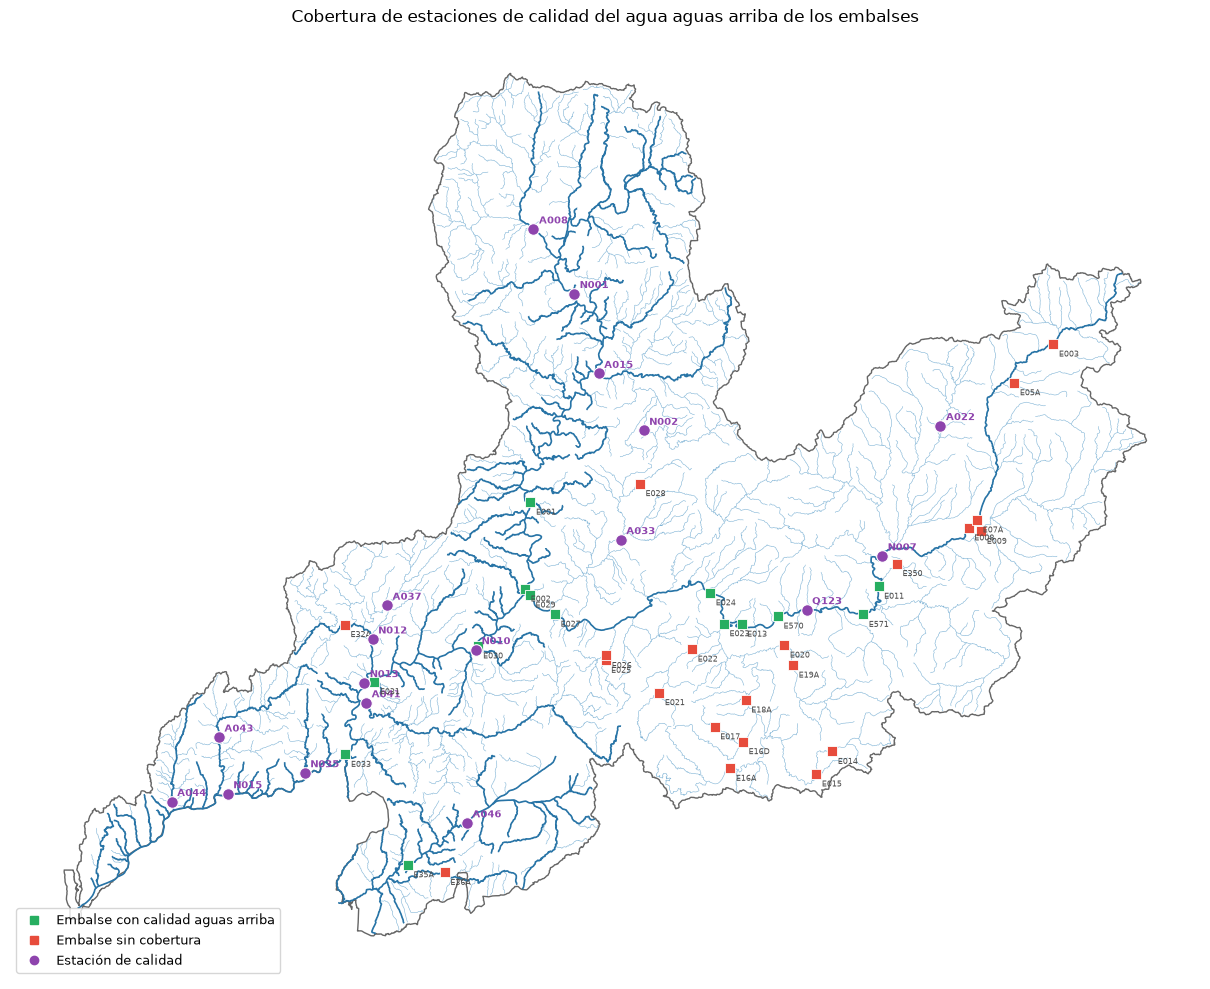

In [32]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

demarcacion = gpd.read_file(DIR_CARTO / "Division_Administrativa" / "Demarcacion_MiñoSil.shp").to_crs(CRS_PROYECTO)

emb_cubiertos = set(valido["ID_emb"])
emb_plot = embalses_gdf.merge(emb_c[["ID", "cauce"]], on="ID", how="left")
emb_plot["cubierto"] = emb_plot["ID"].isin(emb_cubiertos)

fig, ax = plt.subplots(figsize=(14, 10))

demarcacion.boundary.plot(ax=ax, color="0.4", linewidth=1)
cauces.plot(ax=ax, color="#7fb3d5", linewidth=0.4, zorder=1)
# Cauces principales resaltados
principales = cauces[cauces["CODPK"].str.count("-") <= 2]
principales.plot(ax=ax, color="#2874a6", linewidth=1.2, zorder=2)

emb_plot[~emb_plot["cubierto"]].plot(ax=ax, color="#e74c3c", marker="s",
                                     markersize=45, zorder=3, edgecolor="white", linewidth=0.6)
emb_plot[emb_plot["cubierto"]].plot(ax=ax, color="#27ae60", marker="s",
                                    markersize=45, zorder=3, edgecolor="white", linewidth=0.6)
calidad_gdf.plot(ax=ax, color="#8e44ad", marker="o", markersize=70,
                 zorder=4, edgecolor="white", linewidth=0.8)

for _, r in calidad_gdf.iterrows():
    ax.annotate(r["ID"], (r.geometry.x, r.geometry.y), xytext=(4, 4),
                textcoords="offset points", fontsize=7, color="#8e44ad", weight="bold")
for _, r in emb_plot.iterrows():
    ax.annotate(r["ID"], (r.geometry.x, r.geometry.y), xytext=(4, -9),
                textcoords="offset points", fontsize=6, color="0.3")

ax.legend(handles=[
    Line2D([], [], color="#27ae60", marker="s", ls="", label="Embalse con calidad aguas arriba"),
    Line2D([], [], color="#e74c3c", marker="s", ls="", label="Embalse sin cobertura"),
    Line2D([], [], color="#8e44ad", marker="o", ls="", label="Estación de calidad"),
], loc="lower left", fontsize=9)

ax.set_title("Cobertura de estaciones de calidad del agua aguas arriba de los embalses")
ax.set_axis_off()
fig.tight_layout()
fig.savefig("../outputs/figures/5_2_cobertura_calidad_embalses.png", dpi=150, bbox_inches="tight")
plt.show()

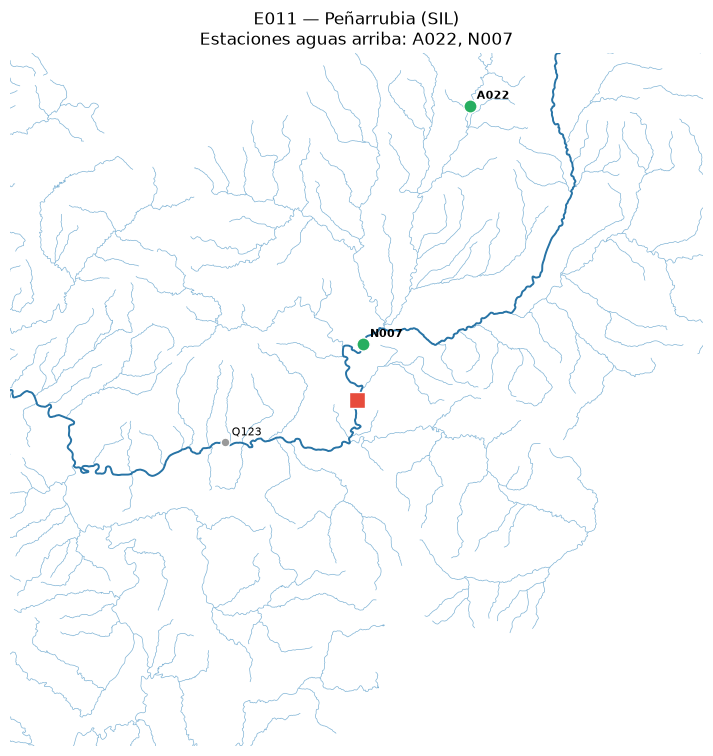

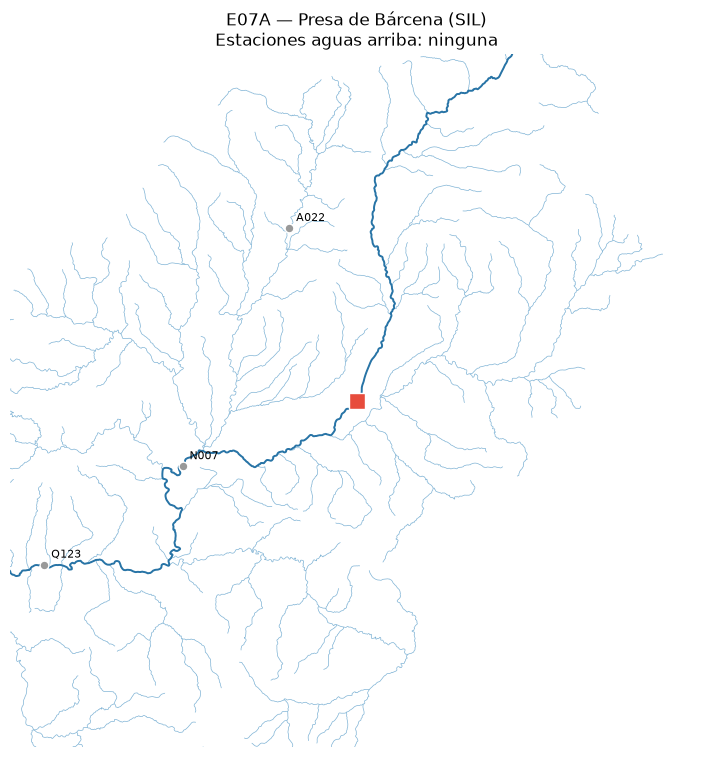

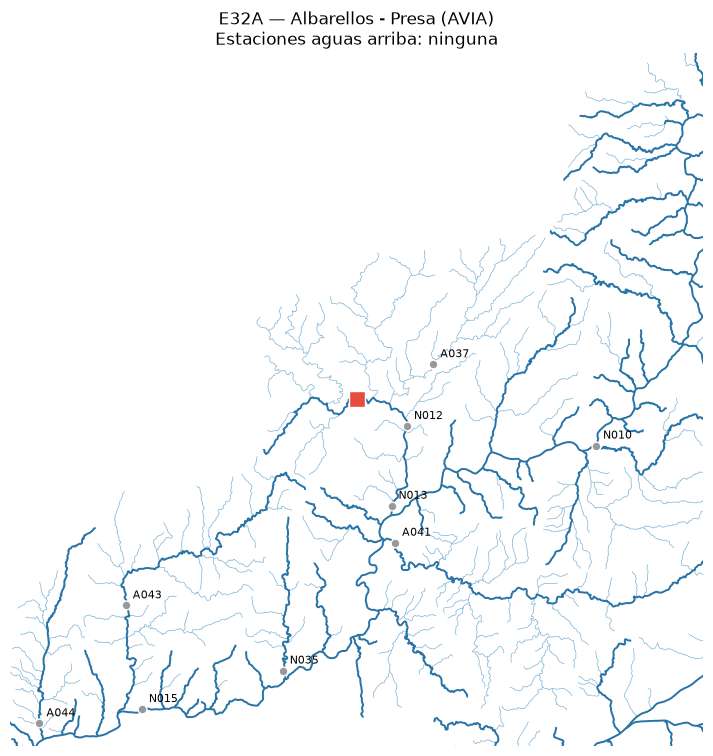

In [33]:
def plot_embalse(id_emb, margen_km=40):
    emb = emb_plot[emb_plot["ID"] == id_emb].iloc[0]
    asignadas = valido.loc[valido["ID_emb"] == id_emb, "ID_cal"].tolist()
    m = margen_km * 1000

    fig, ax = plt.subplots(figsize=(9, 9))
    cauces.plot(ax=ax, color="#7fb3d5", linewidth=0.5)
    principales.plot(ax=ax, color="#2874a6", linewidth=1.4)

    ax.scatter(emb.geometry.x, emb.geometry.y, c="#e74c3c", marker="s", s=140,
               edgecolor="white", zorder=5, label=f"{id_emb} {emb['Nombre']}")

    for _, r in calidad_gdf.iterrows():
        asignada = r["ID"] in asignadas
        ax.scatter(r.geometry.x, r.geometry.y,
                   c="#27ae60" if asignada else "0.6",
                   marker="o", s=90 if asignada else 40,
                   edgecolor="white", zorder=4)
        ax.annotate(r["ID"], (r.geometry.x, r.geometry.y), xytext=(5, 5),
                    textcoords="offset points", fontsize=8,
                    weight="bold" if asignada else "normal")

    ax.set_xlim(emb.geometry.x - m, emb.geometry.x + m)
    ax.set_ylim(emb.geometry.y - m, emb.geometry.y + m)
    ax.set_title(f"{id_emb} — {emb['Nombre']} ({emb['cauce']})\n"
                 f"Estaciones aguas arriba: {', '.join(asignadas) if asignadas else 'ninguna'}")
    ax.set_axis_off()
    plt.show()

plot_embalse("E011")   # Peñarrubia: deberían salir A022 y N007
plot_embalse("E07A")   # Bárcena: no debería salir ninguna pese a tener el Cua cerca
plot_embalse("E32A")   # Albarellos: comprobar que descarta Leiro y Arenteiro

In [34]:
inicio = resumen_cob.set_index("ID")["desde"].to_dict()

for corte, etiqueta in [("2002-01-01", "serie desde 2001"),
                        ("2011-06-30", "serie desde 2011 o antes"),
                        ("2020-12-31", "cualquier serie")]:
    usables = {k for k, v in inicio.items() if v <= pd.Timestamp(corte)}
    v = valido[valido["ID_cal"].isin(usables)]
    print(f"{etiqueta:<28} estaciones: {len(usables):>2} | embalses cubiertos: {v['ID_emb'].nunique()} de 35")

# Embalses que dependen solo de estaciones tardías
tardias = {k for k, v in inicio.items() if v > pd.Timestamp("2011-06-30")}
solo_tardias = (valido.groupby("ID_emb")["ID_cal"]
                .apply(lambda s: set(s).issubset(tardias)))
print(f"\nEmbalses que dependen únicamente de estaciones posteriores a 2011: "
      f"{solo_tardias.sum()}")
if solo_tardias.any():
    print(solo_tardias[solo_tardias].index.tolist())

serie desde 2001             estaciones: 11 | embalses cubiertos: 14 de 35
serie desde 2011 o antes     estaciones: 13 | embalses cubiertos: 14 de 35
cualquier serie              estaciones: 18 | embalses cubiertos: 14 de 35

Embalses que dependen únicamente de estaciones posteriores a 2011: 0


In [35]:
maestro = pd.read_parquet(DIR_PROCESSED / "maestro_embalses.parquet")
print(f"Embalses en el maestro: {len(maestro)}")

emb_raw = pd.read_excel(DIR_RAW / "saih" / "Datos_Embalses.xlsx",
                        sheet_name="Datos_Embalses", skiprows=[1, 2])
emb_raw = emb_raw.rename(columns={emb_raw.columns[0]: "fecha"})

# Columnas de volumen (contempla las tres variantes de código)
VOLUMEN = {"MACVEMBA", "MAIVEMBA", "ACVEMBA"}
cols_vol = {c: id_estacion(c) for c in emb_raw.columns[1:]
            if PATRON_COL.match(str(c).strip())
            and PATRON_COL.match(str(c).strip()).group(2).upper() in VOLUMEN}

largo = (emb_raw[["fecha"] + list(cols_vol)]
         .melt(id_vars="fecha", var_name="col", value_name="volumen_hm3")
         .assign(id_datos=lambda d: d["col"].map(cols_vol))
         .dropna(subset=["volumen_hm3"]))

# Normalizar al identificador del maestro (E016A -> E16A)
largo["ID_SAIH"] = largo["id_datos"].apply(
    lambda x: x if x in set(maestro["ID_SAIH"]) else normalizar_id_embalse(x))

llenado = (largo.merge(maestro[["ID_SAIH", "Capacidad_hm3"]], on="ID_SAIH", how="inner")
           .assign(pct=lambda d: d["volumen_hm3"] / d["Capacidad_hm3"] * 100))

print(f"Embalses con serie de llenado: {llenado['ID_SAIH'].nunique()}")

stats = llenado.groupby("ID_SAIH")["pct"].agg(
    mediana="median", p10=lambda s: s.quantile(0.10), p90=lambda s: s.quantile(0.90))
stats["rango_p10_p90"] = stats["p90"] - stats["p10"]
stats = stats.join(maestro.set_index("ID_SAIH")["Capacidad_hm3"])
stats["cubierto"] = stats.index.isin(emb_cubiertos)

print()
print(stats.groupby("cubierto")[["Capacidad_hm3", "mediana", "rango_p10_p90"]]
      .median().round(1).to_string())
print()
print(stats.sort_values("rango_p10_p90", ascending=False).round(1).to_string())

Embalses en el maestro: 35
Embalses con serie de llenado: 35

          Capacidad_hm3  mediana  rango_p10_p90
cubierto                                       
False              43.0     55.3           42.7
True               14.5     87.7           11.8

         mediana   p10    p90  rango_p10_p90  Capacidad_hm3  cubierto
ID_SAIH                                                              
E003        49.4  10.6   93.7           83.1           28.0     False
E021        51.2  22.2   95.4           73.2           60.6     False
E028        55.3  25.3   93.8           68.4           20.5     False
E026        41.2  23.8   89.5           65.8           10.7     False
E017        60.1  21.5   87.2           65.7           43.0     False
E001        61.5  26.2   90.4           64.1          645.6      True
E05A        54.0  23.3   82.2           58.9           65.0     False
E16A        75.1  37.6   94.3           56.7          535.7     False
E07A        62.9  30.7   86.7           56.0 

In [36]:
def relacion(est, emb):
    """Relación de drenaje entre una estación y un embalse.
    Devuelve 'arriba' si el agua de la estación llega al embalse,
    'abajo' si el agua del embalse llega a la estación, None si no hay conexión."""

    # Mismo cauce: decide la posición relativa respecto a la desembocadura
    if est["codpk"] == emb["codpk"]:
        return "arriba" if est["pos_km"] > emb["pos_km"] else "abajo"

    # La estación cuelga del cauce del embalse -> candidata a aguas arriba
    if est["codpk"].startswith(emb["codpk"] + "-"):
        resto = est["codpk"][len(emb["codpk"]) + 1:].split("-")
        rama = emb["codpk"] + "-" + resto[0]
        if rama in geom_por_codpk and pos_confluencia(rama, emb["codpk"]) > emb["pos_km"]:
            return "arriba"
        return None

    # El embalse cuelga del cauce de la estación -> candidata a aguas abajo
    if emb["codpk"].startswith(est["codpk"] + "-"):
        resto = emb["codpk"][len(est["codpk"]) + 1:].split("-")
        rama = est["codpk"] + "-" + resto[0]
        if rama in geom_por_codpk and pos_confluencia(rama, est["codpk"]) > est["pos_km"]:
            return "abajo"
        return None

    return None

In [37]:
coords_emb = embalses_gdf.set_index("ID").geometry.to_dict()
coords_cal = calidad_gdf.set_index("ID").geometry.to_dict()

pares = emb_c.merge(cal_c, how="cross", suffixes=("_emb", "_cal"))

pares["relacion"] = pares.apply(
    lambda r: relacion(
        {"codpk": r["codpk_cal"], "pos_km": r["pos_km_cal"]},
        {"codpk": r["codpk_emb"], "pos_km": r["pos_km_emb"]}), axis=1)

pares["dist_km"] = pares.apply(
    lambda r: coords_emb[r["ID_emb"]].distance(coords_cal[r["ID_cal"]]) / 1000, axis=1)

conectados = pares[pares["relacion"].notna()].copy()

print("=== Pares conectados hidrológicamente ===")
print(conectados["relacion"].value_counts().to_string())

print("\n=== Cobertura por umbral de distancia ===")
for umbral in [20, 30, 50, 100, 999]:
    sub = conectados[conectados["dist_km"] <= umbral]
    arriba = sub[sub["relacion"] == "arriba"]["ID_emb"].nunique()
    abajo = sub[sub["relacion"] == "abajo"]["ID_emb"].nunique()
    total = sub["ID_emb"].nunique()
    print(f"  <= {umbral:>3} km -> total {total:>2}/35 | con aguas arriba {arriba:>2} | con aguas abajo {abajo:>2}")

=== Pares conectados hidrológicamente ===
relacion
abajo     79
arriba    62

=== Cobertura por umbral de distancia ===
  <=  20 km -> total 14/35 | con aguas arriba  7 | con aguas abajo  9
  <=  30 km -> total 22/35 | con aguas arriba 11 | con aguas abajo 15
  <=  50 km -> total 25/35 | con aguas arriba 13 | con aguas abajo 20
  <= 100 km -> total 34/35 | con aguas arriba 14 | con aguas abajo 33
  <= 999 km -> total 34/35 | con aguas arriba 14 | con aguas abajo 33


In [38]:
UMBRAL_KM = 30
sel = conectados[conectados["dist_km"] <= UMBRAL_KM]

resumen = (sel.groupby(["ID_emb", "Nombre_emb"])
           .apply(lambda g: pd.Series({
               "n_arriba": (g["relacion"] == "arriba").sum(),
               "n_abajo": (g["relacion"] == "abajo").sum(),
               "estaciones": ", ".join(
                   f"{r.ID_cal}({'↑' if r.relacion == 'arriba' else '↓'})"
                   for r in g.sort_values("dist_km").itertuples()),
           }), include_groups=False)
           .reset_index())

sin_cobertura = set(emb_c["ID"]) - set(sel["ID_emb"])
print(f"Embalses sin cobertura a menos de {UMBRAL_KM} km: {sorted(sin_cobertura)}\n")
print(resumen.to_string(index=False))

Embalses sin cobertura a menos de 30 km: ['E003', 'E014', 'E015', 'E017', 'E020', 'E021', 'E022', 'E05A', 'E16A', 'E16D', 'E18A', 'E19A', 'E36A']

ID_emb         Nombre_emb  n_arriba  n_abajo                         estaciones
  E001            Belesar         1        0                            N002(↑)
  E002          Os Peares         0        1                            N010(↓)
  E008  Fuente del Azufre         0        1                            N007(↓)
  E009        Montearenas         0        1                            N007(↓)
  E011         Peñarrubia         1        1                   N007(↑), Q123(↓)
  E013         San Martin         1        0                            Q123(↑)
  E023        Montefurado         1        0                            Q123(↑)
  E024          Sequeiros         1        0                            Q123(↑)
  E025      Leboreiro Mao         0        1                            N010(↓)
  E026         Edrada Mao         0        1         